# Non-Higgs Models to be Sent to Mathematica


To test our framework being used here for our monte carlo set, we needed to define a different inflationary models and inspect to see if the same effect by $\Delta N$ is being observed. 

The relevant papers are here:

For **Deformed Quad** we have already done this in a separate notebook but the relevant paper is here:
https://arxiv.org/abs/2511.05341.

For **Starobinksy** see:

For **Hilltop** see:

For **Natural** see:

For **$\alpha$ - T** see:

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.integrate import solve_ivp, cumulative_trapezoid

from scipy.interpolate import PchipInterpolator



# ============================================================
# Global matplotlib styling
# ============================================================

plt.rcParams.update({

    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",

    "axes.linewidth": 1.4,
    "axes.labelsize": 18,
    "axes.titlesize": 18,

    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,

    "xtick.top": True,
    "ytick.right": True,

    "figure.dpi": 150
})


MODEL: Higgs
Initial phi: 5.4
Final phi: -0.8564378752131839
Initial psi: -1.1473823565017132e-07
Final psi: -2.71002796450714e-07
Maximum remaining N: 61.44220213291778


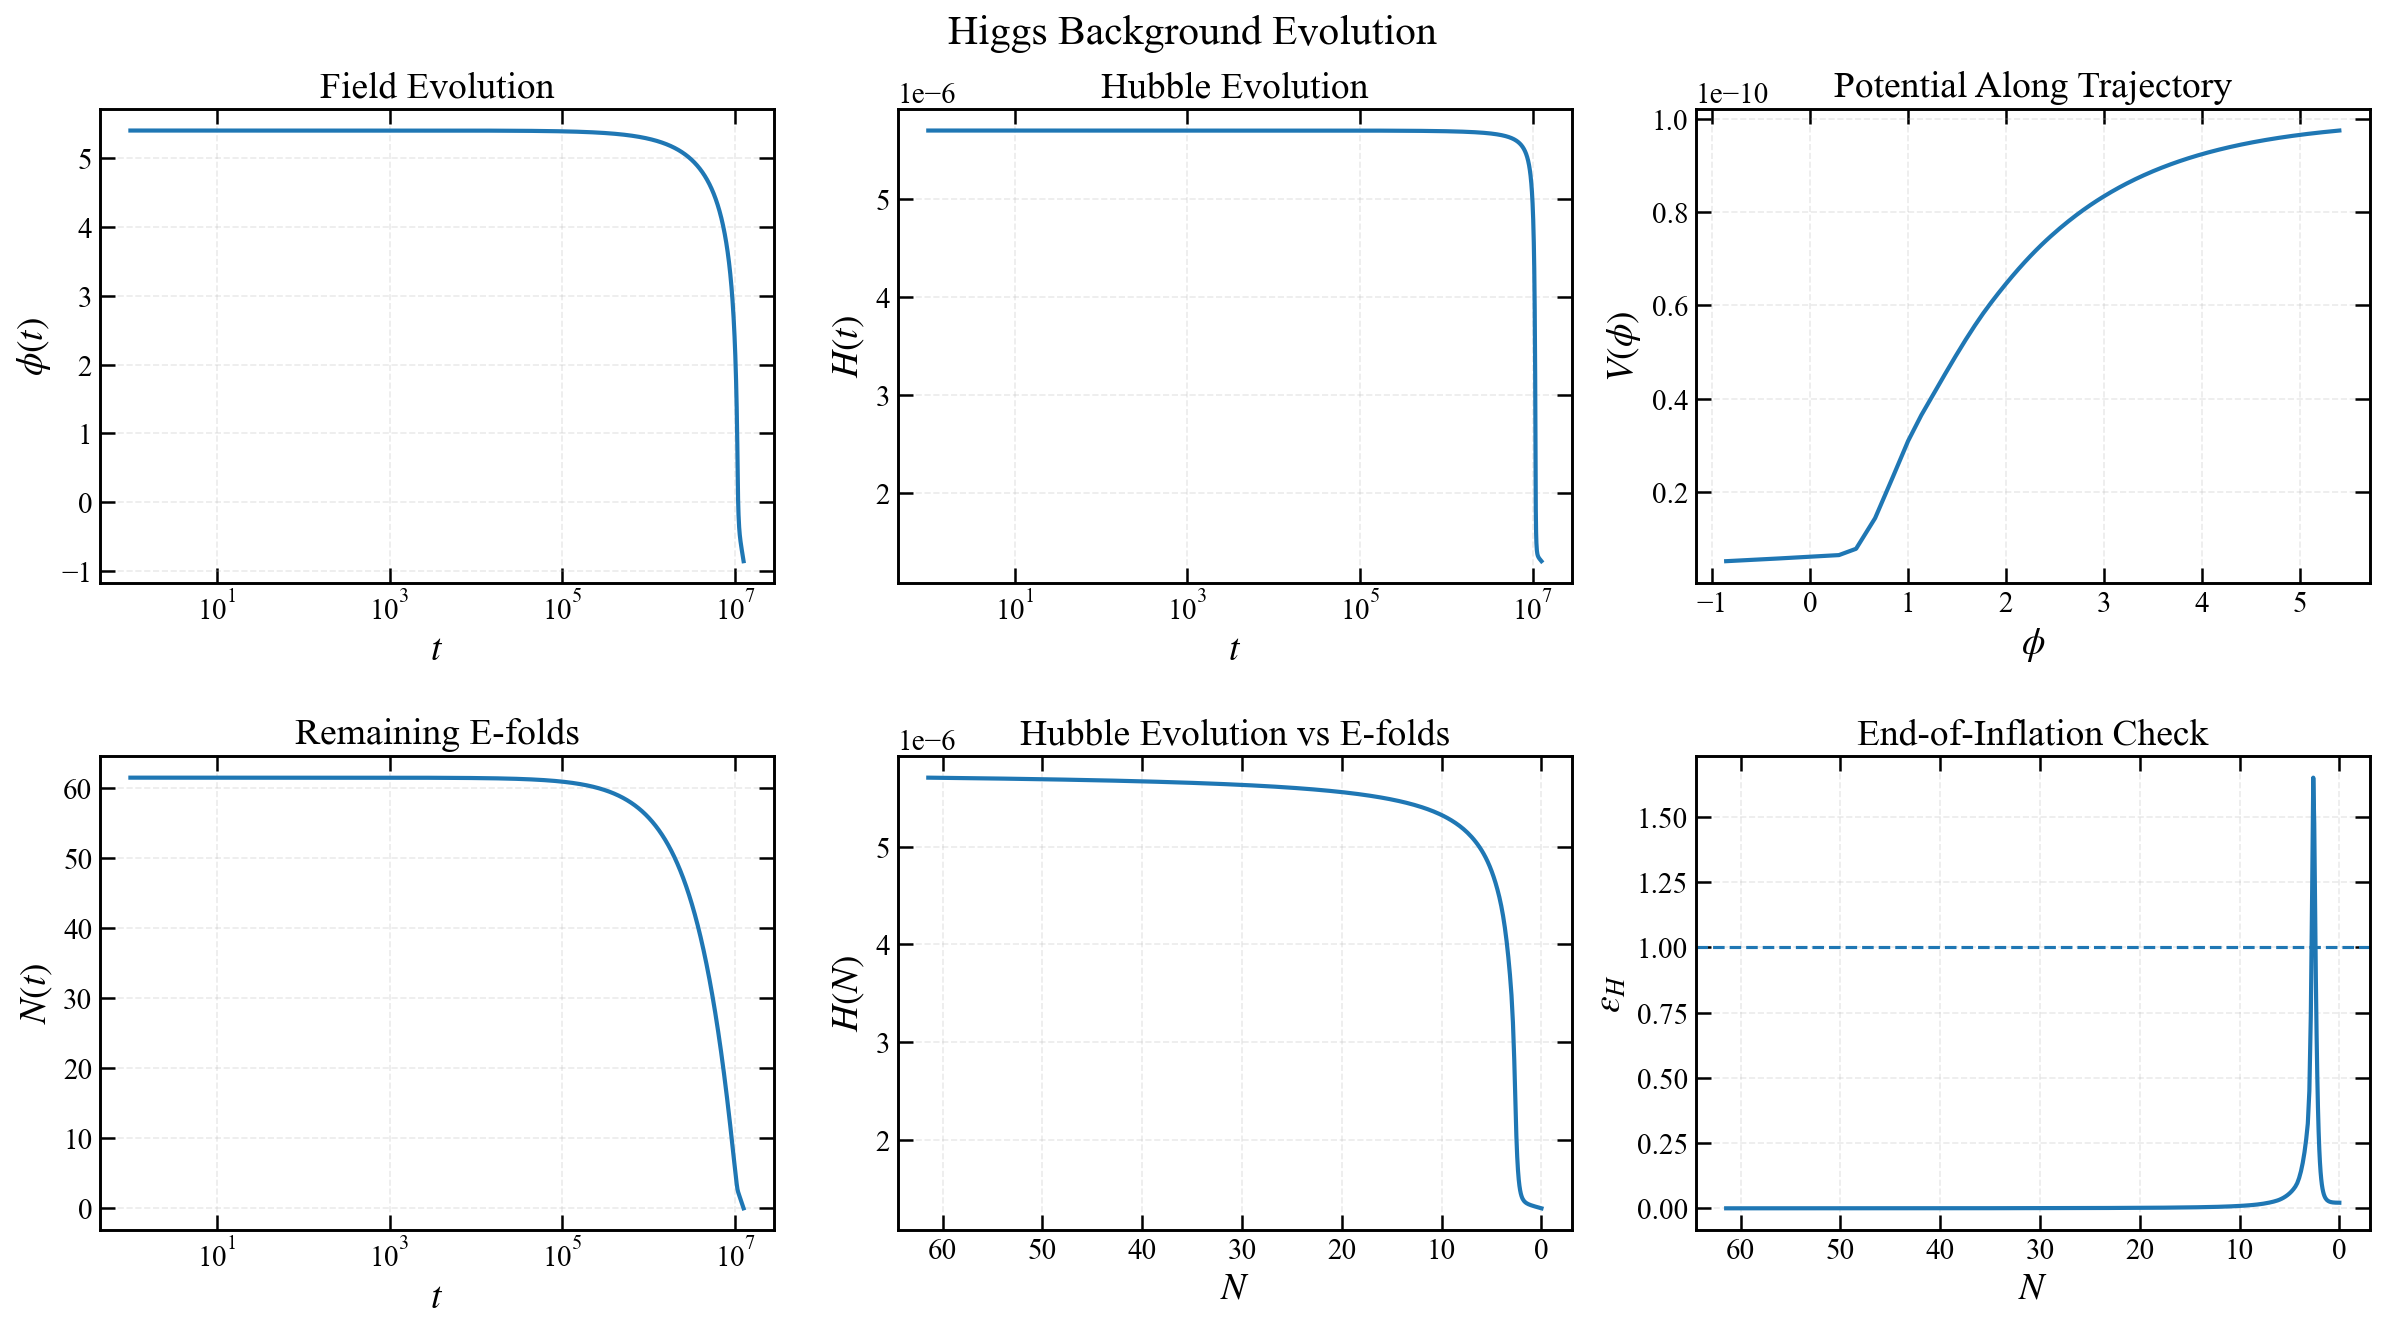


Original points: 4000
After cleaning: 4000
Removed: 0

Higgs results returned only.
Higgs file NOT saved.



In [83]:


# ============================================================
# Model potentials
#
# Reduced Planck units:
# M_pl = 1
# ============================================================


# ------------------------------------------------------------
# 1. Starobinsky
# ------------------------------------------------------------

def V_starobinsky(phi, V0=1e-10):

    a = np.sqrt(2.0 / 3.0)

    return V0 * (
        1.0 - np.exp(-a * phi)
    )**2


def dV_starobinsky(phi, V0=1e-10):

    a = np.sqrt(2.0 / 3.0)

    return (
        2.0
        * V0
        * a
        * np.exp(-a * phi)
        * (
            1.0 - np.exp(-a * phi)
        )
    )


# ------------------------------------------------------------
# 2. Hilltop
# ------------------------------------------------------------

def V_hilltop(
    phi,
    V0=1e-10,
    mu=10.0,
    p=4
):

    return V0 * (
        1.0
        - (phi / mu)**p
    )


def dV_hilltop(
    phi,
    V0=1e-10,
    mu=10.0,
    p=4
):

    return (
        -V0
        * p
        * phi**(p - 1)
        / mu**p
    )


# ------------------------------------------------------------
# 3. Natural inflation
# ------------------------------------------------------------

def V_natural(
    phi,
    V0=1e-10,
    f=6.0
):

    return V0 * (
        1.0
        + np.cos(phi / f)
    )


def dV_natural(
    phi,
    V0=1e-10,
    f=6.0
):

    return (
        -(V0 / f)
        * np.sin(phi / f)
    )


# ------------------------------------------------------------
# 4. Alpha-attractor T-model
# ------------------------------------------------------------

def V_alphaT(
    phi,
    V0=1e-10,
    alpha=1.0
):

    x = (
        phi
        / np.sqrt(6.0 * alpha)
    )

    return (
        V0
        * np.tanh(x)**2
    )


def dV_alphaT(
    phi,
    V0=1e-10,
    alpha=1.0
):

    x = (
        phi
        / np.sqrt(6.0 * alpha)
    )

    prefactor = (
        2.0
        * V0
        / np.sqrt(6.0 * alpha)
    )

    return (
        prefactor
        * np.tanh(x)
        / np.cosh(x)**2
    )


# ------------------------------------------------------------
# 5. Deformed quadratic
# ------------------------------------------------------------

def V_deformed_quad(
    phi,
    m=1e-3,
    gamma=1.5e-8
):

    return (
        0.5
        * m**2
        * (
            phi
            - (gamma / 14.0)
            * phi**7
        )**2
    )


def dV_deformed_quad(
    phi,
    m=1e-3,
    gamma=1.5e-8
):

    return (
        m**2 * phi
        - m**2
        * (4.0 * gamma / 7.0)
        * phi**7
        + m**2
        * (gamma**2 / 28.0)
        * phi**13
    )


# ============================================================
# Model selector
# ============================================================

def get_model(model_name):

    model_name = model_name.lower()


    if model_name == "starobinsky":

        return {

            "name": "Starobinsky",

            "V": lambda phi: V_starobinsky(
                phi,
                V0=1e-10
            ),

            "dV": lambda phi: dV_starobinsky(
                phi,
                V0=1e-10
            ),

            "phi0": 5.61,

            "plot_range": (
                0.0,
                7.0
            )
        }


    elif model_name == "hilltop":

        return {

            "name": "Hilltop",

            "V": lambda phi: V_hilltop(
                phi,
                V0=1e-10,
                mu=10.0,
                p=4
            ),

            "dV": lambda phi: dV_hilltop(
                phi,
                V0=1e-10,
                mu=10.0,
                p=4
            ),

            "phi0": 3.65,

            "plot_range": (
                0.0,
                9.9
            )
        }


    elif model_name == "natural":

        return {

            "name": "Natural",

            "V": lambda phi: V_natural(
                phi,
                V0=1e-10,
                f=6.0
            ),

            "dV": lambda phi: dV_natural(
                phi,
                V0=1e-10,
                f=6.0
            ),

            "phi0": 4.6,

            "plot_range": (
                0.0,
                np.pi * 6.0
            )
        }


    elif model_name == "alphat":

        return {

            "name": "AlphaT",

            "V": lambda phi: V_alphaT(
                phi,
                V0=1e-10,
                alpha=1.0
            ),

            "dV": lambda phi: dV_alphaT(
                phi,
                V0=1e-10,
                alpha=1.0
            ),

            "phi0": 6.4,

            "plot_range": (
                0.0,
                7.0
            )
        }


    elif model_name == "deformed_quad":

        return {

            "name": "Deformed Quadratic",

            "V": lambda phi: V_deformed_quad(
                phi,
                m=1e-3,
                gamma=1.5e-8
            ),

            "dV": lambda phi: dV_deformed_quad(
                phi,
                m=1e-3,
                gamma=1.5e-8
            ),

            "phi0": 16.4,

            "plot_range": (
                0.0,
                25.0
            )
        }


    else:

        raise ValueError(
            "Unknown model. Use:\n"
            "'Starobinsky'\n"
            "'Hilltop'\n"
            "'Natural'\n"
            "'AlphaT'\n"
            "'Deformed_Quad'\n"
            "'Higgs'"
        )


# ============================================================
# Generic background dynamics
#
# Used for:
# Starobinsky
# Hilltop
# Natural
# AlphaT
# Deformed quadratic
# ============================================================

def inflation_dynamics(
    model_name,
    phi0=None,
    t_eval=None,
    rtol=1e-9,
    atol=1e-11
):

    model = get_model(
        model_name
    )

    V = model["V"]
    dV = model["dV"]

    if phi0 is None:

        phi0 = model["phi0"]


    if t_eval is None:

        t_eval = np.logspace(
            0,
            7.5,
            4000
        )


    t_span = (
        t_eval[0],
        t_eval[-1]
    )


    # --------------------------------------------------------
    # Friedmann equation
    # --------------------------------------------------------

    def H_friedmann(
        phi,
        psi
    ):

        rho = (
            0.5 * psi**2
            + V(phi)
        )

        return np.sqrt(
            np.maximum(
                rho,
                0.0
            )
            / 3.0
        )


    # --------------------------------------------------------
    # Klein-Gordon + Friedmann
    # --------------------------------------------------------

    def kg_friedmann(
        t,
        y
    ):

        phi, psi = y

        H = H_friedmann(
            phi,
            psi
        )

        dV_dphi = dV(phi)

        return [
            psi,
            -3.0 * H * psi
            - dV_dphi
        ]


    # --------------------------------------------------------
    # End of inflation:
    #
    # epsilon_H = psi^2 / (2 H^2)
    # --------------------------------------------------------

    def end_inflation(
        t,
        y
    ):

        phi, psi = y

        H = H_friedmann(
            phi,
            psi
        )

        if H <= 0:

            return 0.0

        epsilon_H = (
            psi**2
            / (
                2.0
                * H**2
            )
        )

        return (
            epsilon_H
            - 1.0
        )


    end_inflation.terminal = True
    end_inflation.direction = 1


    # --------------------------------------------------------
    # Slow-roll initial velocity
    # --------------------------------------------------------

    V0_initial = V(phi0)

    dV0_initial = dV(phi0)

    H_slowroll = np.sqrt(
        V0_initial
        / 3.0
    )

    psi0 = (
        -dV0_initial
        / (
            3.0
            * H_slowroll
        )
    )

    y0 = [
        phi0,
        psi0
    ]


    # --------------------------------------------------------
    # Solve
    # --------------------------------------------------------

    sol = solve_ivp(

        kg_friedmann,

        t_span,

        y0,

        t_eval=t_eval,

        events=end_inflation,

        method="RK45",

        rtol=rtol,

        atol=atol
    )


    # --------------------------------------------------------
    # Extract solution
    # --------------------------------------------------------

    t_soln = sol.t

    phi_t = sol.y[0]

    psi_t = sol.y[1]


    # --------------------------------------------------------
    # Append exact epsilon_H = 1 event point
    # --------------------------------------------------------

    if len(sol.t_events[0]) > 0:

        t_event = (
            sol.t_events[0][0]
        )

        phi_event = (
            sol.y_events[0][0][0]
        )

        psi_event = (
            sol.y_events[0][0][1]
        )

        if t_event > t_soln[-1]:

            t_soln = np.append(
                t_soln,
                t_event
            )

            phi_t = np.append(
                phi_t,
                phi_event
            )

            psi_t = np.append(
                psi_t,
                psi_event
            )


    H_t = H_friedmann(
        phi_t,
        psi_t
    )

    V_t = V(
        phi_t
    )


    # --------------------------------------------------------
    # Remaining e-folds
    # --------------------------------------------------------

    N_count = cumulative_trapezoid(
        H_t,
        t_soln,
        initial=0.0
    )

    N_remaining = (
        N_count[-1]
        - N_count
    )


    # --------------------------------------------------------
    # epsilon_H diagnostic
    # --------------------------------------------------------

    epsilon_H = (
        psi_t**2
        / (
            2.0
            * H_t**2
        )
    )


    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    print()

    print(
        "=" * 60
    )

    print(
        f"MODEL: {model['name']}"
    )

    print(
        "=" * 60
    )

    print(
        "Integration success:",
        sol.success
    )

    print(
        "Message:",
        sol.message
    )

    print()

    print(
        "Initial phi:",
        phi_t[0]
    )

    print(
        "Final phi:",
        phi_t[-1]
    )

    print()

    print(
        "Initial psi:",
        psi_t[0]
    )

    print(
        "Final psi:",
        psi_t[-1]
    )

    print()

    print(
        "Initial epsilon_H:",
        epsilon_H[0]
    )

    print(
        "Final epsilon_H:",
        epsilon_H[-1]
    )

    print()

    print(
        "Maximum remaining N:",
        N_remaining[0]
    )


    if len(sol.t_events[0]) > 0:

        print(
            "epsilon_H = 1 reached:",
            True
        )

        print(
            "t_end:",
            sol.t_events[0][0]
        )

    else:

        print(
            "epsilon_H = 1 reached:",
            False
        )


    print(
        "=" * 60
    )


    return (
        phi_t,
        H_t,
        V_t,
        t_soln,
        psi_t,
        N_remaining,
        epsilon_H
    )


# ============================================================
# Higgs dynamics
#
# LEFT PHYSICALLY AS YOU HAD IT
# ============================================================

def higgs_dynamics(
    phijm_values,
    lambda_higgs,
    xi,
    mp
):

    def phi_mp_func(
        phi_jm,
        xi
    ):

        term1 = (
            np.sqrt(
                (1 + 6 * xi)
                / xi
            )
            * np.arcsinh(
                np.sqrt(
                    xi
                    * (1 + 6 * xi)
                )
                * phi_jm
            )
        )

        term2 = (
            np.sqrt(6)
            * np.arcsinh(
                np.sqrt(
                    (
                        6
                        * xi**2
                        * phi_jm**2
                    )
                    / (
                        1
                        + xi
                        * phi_jm**2
                    )
                )
            )
        )

        return (
            term1
            - term2
        )


    # --------------------------------------------------------
    # Define Einstein-frame field
    # --------------------------------------------------------

    phi_m = phi_mp_func(
        phijm_values,
        xi
    )


    # --------------------------------------------------------
    # Define potential
    # --------------------------------------------------------

    omega = np.sqrt(
        1
        + xi
        * phijm_values**2
    )

    V_jordan = (
        lambda_higgs
        / 4
    ) * phijm_values**4

    V_phi = (
        1
        / omega**4
    ) * V_jordan


    V_phi_interp = PchipInterpolator(
        phi_m,
        V_phi
    )


    # --------------------------------------------------------
    # Friedmann
    # --------------------------------------------------------

    def H_friedmann(
        phi,
        psi
    ):

        return np.sqrt(
            (
                0.5
                * psi**2
                + V_phi_interp(phi)
            )
            / 3
        )


    # --------------------------------------------------------
    # KG + Friedmann
    # --------------------------------------------------------

    def kg_friedmann(
        t,
        y
    ):

        phi, psi = y

        H = H_friedmann(
            phi,
            psi
        )

        dV_dphi = (
            V_phi_interp
            .derivative()(phi)
        )

        return [
            psi,
            -3
            * H
            * psi
            - dV_dphi
        ]


    # --------------------------------------------------------
    # Duration
    # --------------------------------------------------------

    t_eval = np.logspace(
        0,
        7.1,
        4000
    )

    t_span = (
        t_eval[0],
        t_eval[-1]
    )


    # --------------------------------------------------------
    # Initial parameters
    # --------------------------------------------------------

    phi0 = 5.4


    V0 = V_phi_interp(
        phi0
    )

    dV_dphi0 = (
        V_phi_interp
        .derivative()(phi0)
    )

    H_slowroll = np.sqrt(
        V0
        / 3
    )

    psi0 = (
        -dV_dphi0
        / (
            3
            * H_slowroll
        )
    )

    y0 = [
        phi0,
        psi0
    ]


    # --------------------------------------------------------
    # Integrator
    # --------------------------------------------------------

    sol = solve_ivp(

        kg_friedmann,

        t_span,

        y0,

        t_eval=t_eval,

        method="RK45",

        rtol=1e-8,

        atol=1e-10
    )


    t_soln = sol.t

    phi_t = sol.y[0]

    psi_t = sol.y[1]


    # --------------------------------------------------------
    # H and V
    # --------------------------------------------------------

    H_t = H_friedmann(
        phi_t,
        psi_t
    )

    V_t = V_phi_interp(
        phi_t
    )


    # --------------------------------------------------------
    # Remaining e-folds
    # --------------------------------------------------------

    N_count = cumulative_trapezoid(
        H_t,
        t_soln,
        initial=0
    )

    N_count_convention = (
        N_count[-1]
        - N_count
    )


    print()

    print(
        "=" * 60
    )

    print(
        "MODEL: Higgs"
    )

    print(
        "=" * 60
    )

    print(
        "Initial phi:",
        phi_t[0]
    )

    print(
        "Final phi:",
        phi_t[-1]
    )

    print(
        "Initial psi:",
        psi_t[0]
    )

    print(
        "Final psi:",
        psi_t[-1]
    )

    print(
        "Maximum remaining N:",
        N_count_convention[0]
    )

    print(
        "=" * 60
    )


    return (
        phi_t,
        H_t,
        V_t,
        t_soln,
        psi_t,
        N_count_convention
    )


# ============================================================
# Clean monotonic phi array
# ============================================================

def dedup_monotonic(
    phi,
    H,
    V,
    N,
    tol=1e-10
):

    decreasing = (
        phi[-1]
        < phi[0]
    )

    keep = [
        0
    ]


    for i in range(
        1,
        len(phi)
    ):

        previous = (
            phi[
                keep[-1]
            ]
        )

        if decreasing:

            if (
                phi[i]
                < previous
                - tol
            ):

                keep.append(
                    i
                )

        else:

            if (
                phi[i]
                > previous
                + tol
            ):

                keep.append(
                    i
                )


    keep = np.array(
        keep
    )


    return (
        phi[keep],
        H[keep],
        V[keep],
        N[keep]
    )


# ============================================================
# Trajectory sanity check
# ============================================================

def check_trajectory(
    phi,
    H,
    V,
    N,
    epsilon_H
):

    dphi = np.diff(
        phi
    )

    monotonic_increasing = np.all(
        dphi > 0
    )

    monotonic_decreasing = np.all(
        dphi < 0
    )


    print()

    print(
        "H positive:",
        np.all(H > 0)
    )

    print(
        "V positive:",
        np.all(V > 0)
    )

    print(
        "phi monotonic:",
        monotonic_increasing
        or monotonic_decreasing
    )


    if monotonic_increasing:

        direction = (
            "increasing"
        )

    elif monotonic_decreasing:

        direction = (
            "decreasing"
        )

    else:

        direction = (
            "not monotonic"
        )


    print(
        "direction:",
        direction
    )

    print(
        "epsilon initial:",
        epsilon_H[0]
    )

    print(
        "epsilon final:",
        epsilon_H[-1]
    )

    print(
        "N max:",
        N[0]
    )


# ============================================================
# Plot analytic potential
# ============================================================

def plot_potential(
    model_name
):

    model = get_model(
        model_name
    )

    V = model["V"]

    (
        phi_min,
        phi_max
    ) = model["plot_range"]


    phi_vals = np.linspace(
        phi_min,
        phi_max,
        2000
    )

    V_vals = V(
        phi_vals
    )


    fig, ax = plt.subplots(
        figsize=(
            7.5,
            5.5
        )
    )


    ax.plot(
        phi_vals,
        V_vals,
        linewidth=2.2
    )


    ax.set_xlabel(
        r"$\phi$"
    )

    ax.set_ylabel(
        r"$V(\phi)$"
    )


    ax.set_title(
        f"{model['name']} Inflation Potential",
        pad=12
    )


    ax.xaxis.set_minor_locator(
        AutoMinorLocator()
    )

    ax.yaxis.set_minor_locator(
        AutoMinorLocator()
    )


    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )


    ax.grid(
        alpha=0.25,
        linestyle="--"
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# Plot trajectory
# ============================================================

def plot_background(
    model_name,
    phi,
    H,
    V,
    t,
    N,
    epsilon_H
):

    fig, axs = plt.subplots(
        2,
        3,
        figsize=(
            16,
            9
        )
    )


    # phi(t)
    axs[0, 0].plot(
        t,
        phi,
        linewidth=2.0
    )

    axs[0, 0].set_xscale(
        "log"
    )

    axs[0, 0].set_xlabel(
        r"$t$"
    )

    axs[0, 0].set_ylabel(
        r"$\phi(t)$"
    )

    axs[0, 0].set_title(
        "Field Evolution"
    )


    # H(t)
    axs[0, 1].plot(
        t,
        H,
        linewidth=2.0
    )

    axs[0, 1].set_xscale(
        "log"
    )

    axs[0, 1].set_xlabel(
        r"$t$"
    )

    axs[0, 1].set_ylabel(
        r"$H(t)$"
    )

    axs[0, 1].set_title(
        "Hubble Evolution"
    )


    # V(phi)
    axs[0, 2].plot(
        phi,
        V,
        linewidth=2.0
    )

    axs[0, 2].set_xlabel(
        r"$\phi$"
    )

    axs[0, 2].set_ylabel(
        r"$V(\phi)$"
    )

    axs[0, 2].set_title(
        "Potential Along Trajectory"
    )


    # N(t)
    axs[1, 0].plot(
        t,
        N,
        linewidth=2.0
    )

    axs[1, 0].set_xscale(
        "log"
    )

    axs[1, 0].set_xlabel(
        r"$t$"
    )

    axs[1, 0].set_ylabel(
        r"$N(t)$"
    )

    axs[1, 0].set_title(
        "Remaining E-folds"
    )


    # H(N)
    axs[1, 1].plot(
        N,
        H,
        linewidth=2.0
    )

    axs[1, 1].set_xlabel(
        r"$N$"
    )

    axs[1, 1].set_ylabel(
        r"$H(N)$"
    )

    axs[1, 1].set_title(
        "Hubble Evolution vs E-folds"
    )

    axs[1, 1].invert_xaxis()


    # epsilon_H(N)
    axs[1, 2].plot(
        N,
        epsilon_H,
        linewidth=2.0
    )

    axs[1, 2].axhline(
        1.0,
        linestyle="--"
    )

    axs[1, 2].set_xlabel(
        r"$N$"
    )

    axs[1, 2].set_ylabel(
        r"$\epsilon_H$"
    )

    axs[1, 2].set_title(
        r"End-of-Inflation Check"
    )

    axs[1, 2].invert_xaxis()


    for ax in axs.flat:

        ax.grid(
            alpha=0.25,
            linestyle="--"
        )

        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True
        )


    if model_name.lower() == "higgs":

        title_name = (
            "Higgs"
        )

    else:

        title_name = (
            get_model(
                model_name
            )["name"]
        )


    fig.suptitle(
        f"{title_name} Background Evolution",
        fontsize=20
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# Full model run
# ============================================================

def run_model(
    model_name,
    phi0=None
):

    model_key = (
        model_name.lower()
    )


    # ========================================================
    # HIGGS
    #
    # IMPORTANT:
    # Higgs is NOT saved to disk.
    # ========================================================

    if model_key == "higgs":

        lambda_higgs = (
            0.01
        )

        xi = (
            5e4
            * np.sqrt(
                lambda_higgs
            )
        )

        mp = (
            1.0
        )

        phijm_range = np.linspace(
            -1,
            35,
            4000
        )


        (
            phi_t,
            H_t,
            V_t,
            t,
            psi_t,
            N_t
        ) = higgs_dynamics(

            phijm_range,

            lambda_higgs,

            xi,

            mp
        )


        epsilon_H = (
            psi_t**2
            / (
                2.0
                * H_t**2
            )
        )


        plot_background(
            "Higgs",
            phi_t,
            H_t,
            V_t,
            t,
            N_t,
            epsilon_H
        )


        (
            phi_clean,
            H_clean,
            V_clean,
            N_clean
        ) = dedup_monotonic(

            phi_t,
            H_t,
            V_t,
            N_t
        )


        print()

        print(
            "Original points:",
            len(phi_t)
        )

        print(
            "After cleaning:",
            len(phi_clean)
        )

        print(
            "Removed:",
            len(phi_t)
            - len(phi_clean)
        )

        print()

        print(
            "Higgs results returned only."
        )

        print(
            "Higgs file NOT saved."
        )

        print()


        return (
            phi_clean,
            H_clean,
            V_clean,
            N_clean
        )


    # ========================================================
    # ALL OTHER MODELS
    # ========================================================

    else:

        plot_potential(
            model_name
        )


        (
            phi_t,
            H_t,
            V_t,
            t,
            psi_t,
            N_t,
            epsilon_H
        ) = inflation_dynamics(

            model_name,

            phi0=phi0
        )


        plot_background(
            model_name,
            phi_t,
            H_t,
            V_t,
            t,
            N_t,
            epsilon_H
        )


        check_trajectory(
            phi_t,
            H_t,
            V_t,
            N_t,
            epsilon_H
        )


        (
            phi_clean,
            H_clean,
            V_clean,
            N_clean
        ) = dedup_monotonic(

            phi_t,
            H_t,
            V_t,
            N_t
        )


        print()

        print(
            "Original points:",
            len(phi_t)
        )

        print(
            "After cleaning:",
            len(phi_clean)
        )

        print(
            "Removed:",
            len(phi_t)
            - len(phi_clean)
        )


        model = get_model(
            model_name
        )


        clean_name = (
            model["name"]
            .replace(
                " ",
                "_"
            )
        )


        filename = (
            f"phi_H_V_N_clean_{clean_name}.csv"
        )


        np.savetxt(

            filename,

            np.column_stack([
                phi_clean,
                H_clean,
                V_clean,
                N_clean
            ]),

            delimiter=",",

            header="phi,H,V,N",

            comments=""
        )


        print()

        print(
            "Saved:",
            filename
        )

        print()


        return (
            phi_clean,
            H_clean,
            V_clean,
            N_clean
        )


# ============================================================
# Example calls
# ============================================================


# Single models:

# phi, H, V, N = run_model("Starobinsky")

# phi, H, V, N = run_model("Hilltop")

# phi, H, V, N = run_model("Natural")

# phi, H, V, N = run_model("AlphaT")

# phi, H, V, N = run_model("Deformed_Quad")

phi, H, V, N = run_model("Higgs")


# ============================================================
# Run full model set
#
# Higgs will be calculated and plotted,
# but it WILL NOT be saved.
# ============================================================

# models = [
#     "Higgs",
#     "Starobinsky",
#     "Hilltop",
#     "Natural",
#     "AlphaT",
#     "Deformed_Quad"
# ]


# for model in models:

#     run_model(
#         model
#     )

## Need to check and make sure they are the same.

Generally, Starobinsky should mimic Higgs and have a plateau. Should start near V=0 and phi=0. Hilltop should be concave, max near phi=0 and decreases as phi moves from top. Natural have a cosine like HUMP near phi=0. alpha should asymptote to a plateau.

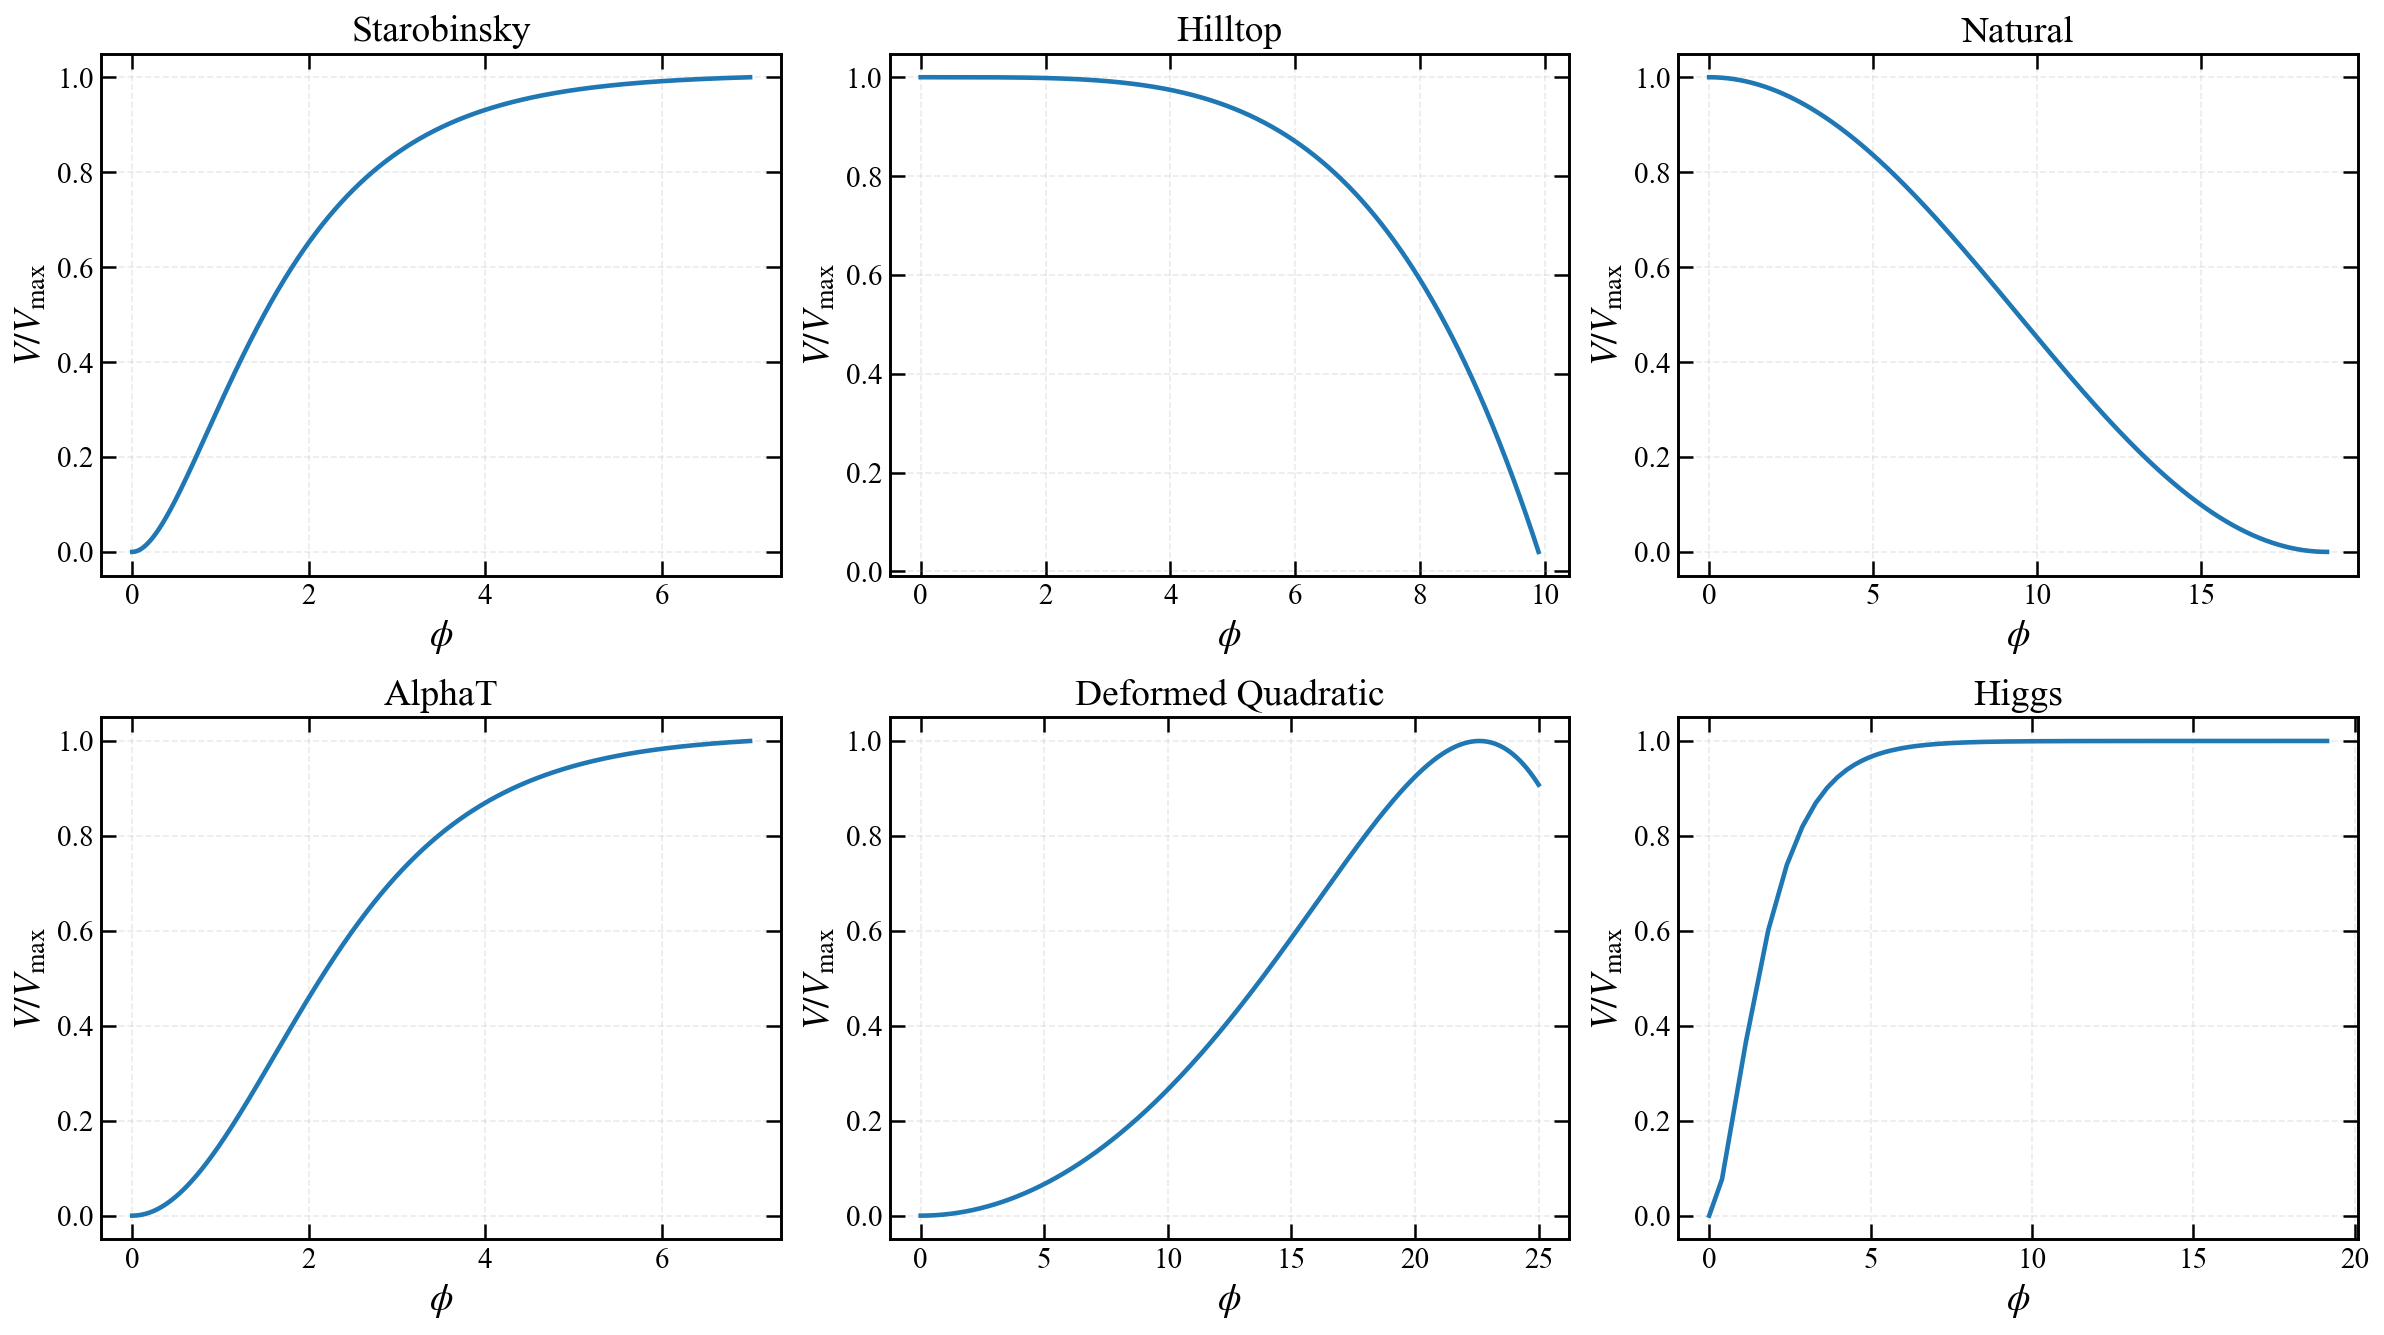

In [84]:
models = [
    "starobinsky",
    "hilltop",
    "natural",
    "alphaT",
    "deformed_quad",
    "higgs"
]


fig, axs = plt.subplots(
    2,
    3,
    figsize=(16, 9)
)


for ax, model_name in zip(
    axs.flat,
    models
):


    # ========================================================
    # Higgs special case
    # ========================================================

    if model_name.lower() == "higgs":

        lambda_higgs = 0.01

        xi = (
            5e4
            * np.sqrt(lambda_higgs)
        )


        # Jordan-frame field range
        phijm_vals = np.linspace(
            0.0,
            35.0,
            4000
        )


        # --------------------------------------------
        # Jordan -> Einstein field mapping
        # --------------------------------------------

        term1 = (
            np.sqrt(
                (1 + 6 * xi)
                / xi
            )
            * np.arcsinh(
                np.sqrt(
                    xi
                    * (1 + 6 * xi)
                )
                * phijm_vals
            )
        )


        term2 = (
            np.sqrt(6)
            * np.arcsinh(
                np.sqrt(
                    (
                        6
                        * xi**2
                        * phijm_vals**2
                    )
                    / (
                        1
                        + xi
                        * phijm_vals**2
                    )
                )
            )
        )


        phi_vals = (
            term1
            - term2
        )


        # --------------------------------------------
        # Einstein-frame Higgs potential
        # --------------------------------------------

        omega = np.sqrt(
            1
            + xi
            * phijm_vals**2
        )


        V_jordan = (
            lambda_higgs
            / 4.0
        ) * phijm_vals**4


        V_vals = (
            V_jordan
            / omega**4
        )


        title_name = "Higgs"


    # ========================================================
    # All other models
    # ========================================================

    else:

        model = get_model(
            model_name
        )


        V = model["V"]


        phi_min, phi_max = (
            model["plot_range"]
        )


        phi_vals = np.linspace(
            phi_min,
            phi_max,
            2000
        )


        V_vals = V(
            phi_vals
        )


        title_name = (
            model["name"]
        )


    # ========================================================
    # Normalize purely to compare SHAPE
    # ========================================================

    V_norm = (
        V_vals
        / np.max(V_vals)
    )


    # ========================================================
    # Plot
    # ========================================================

    ax.plot(
        phi_vals,
        V_norm,
        linewidth=2.2
    )


    ax.set_xlabel(
        r"$\phi$"
    )


    ax.set_ylabel(
        r"$V/V_{\rm max}$"
    )


    ax.set_title(
        title_name
    )


    ax.grid(
        alpha=0.25,
        linestyle="--"
    )


    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )


plt.tight_layout()

plt.show()

Cleaner comparison:

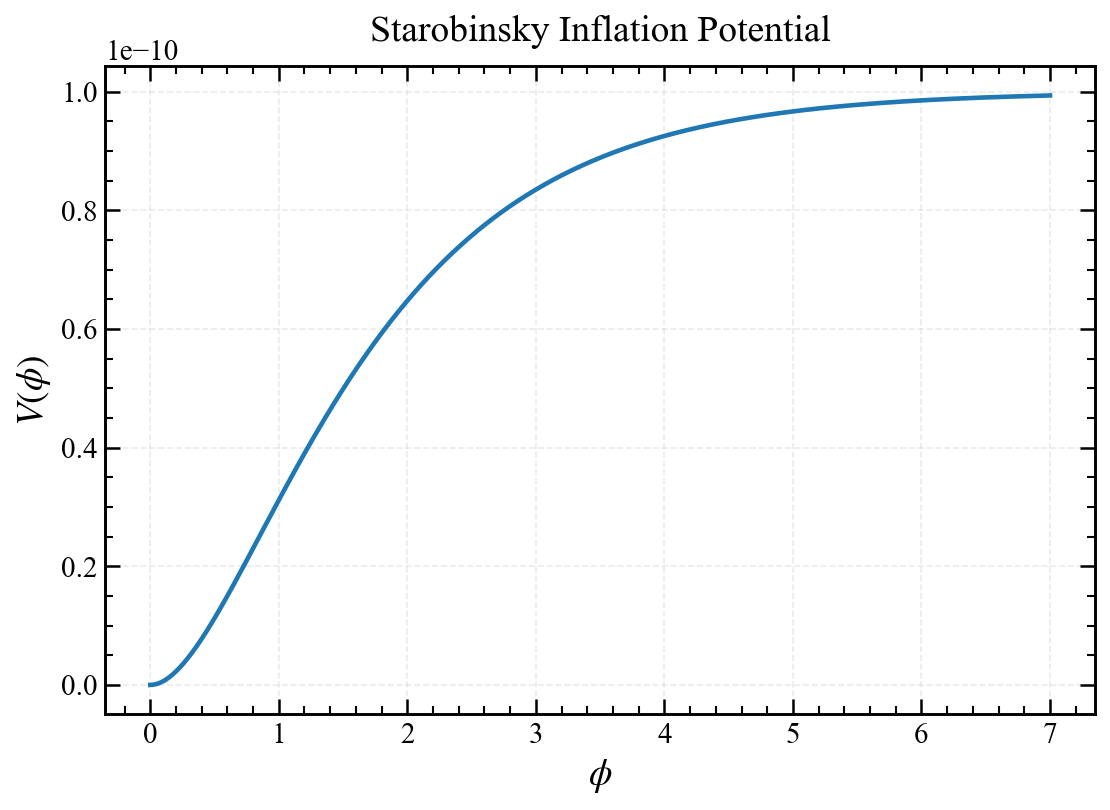


MODEL: Starobinsky
Integration success: True
Message: A termination event occurred.

Initial phi: 5.61
Final phi: 0.6146439946707516

Initial psi: -9.663133187324614e-08
Final psi: -3.945932423312368e-06

Initial epsilon_H: 0.0001429732723333436
Final epsilon_H: 1.0000000000000009

Maximum remaining N: 70.26502651581862
epsilon_H = 1 reached: True
t_end: 12722782.45912737


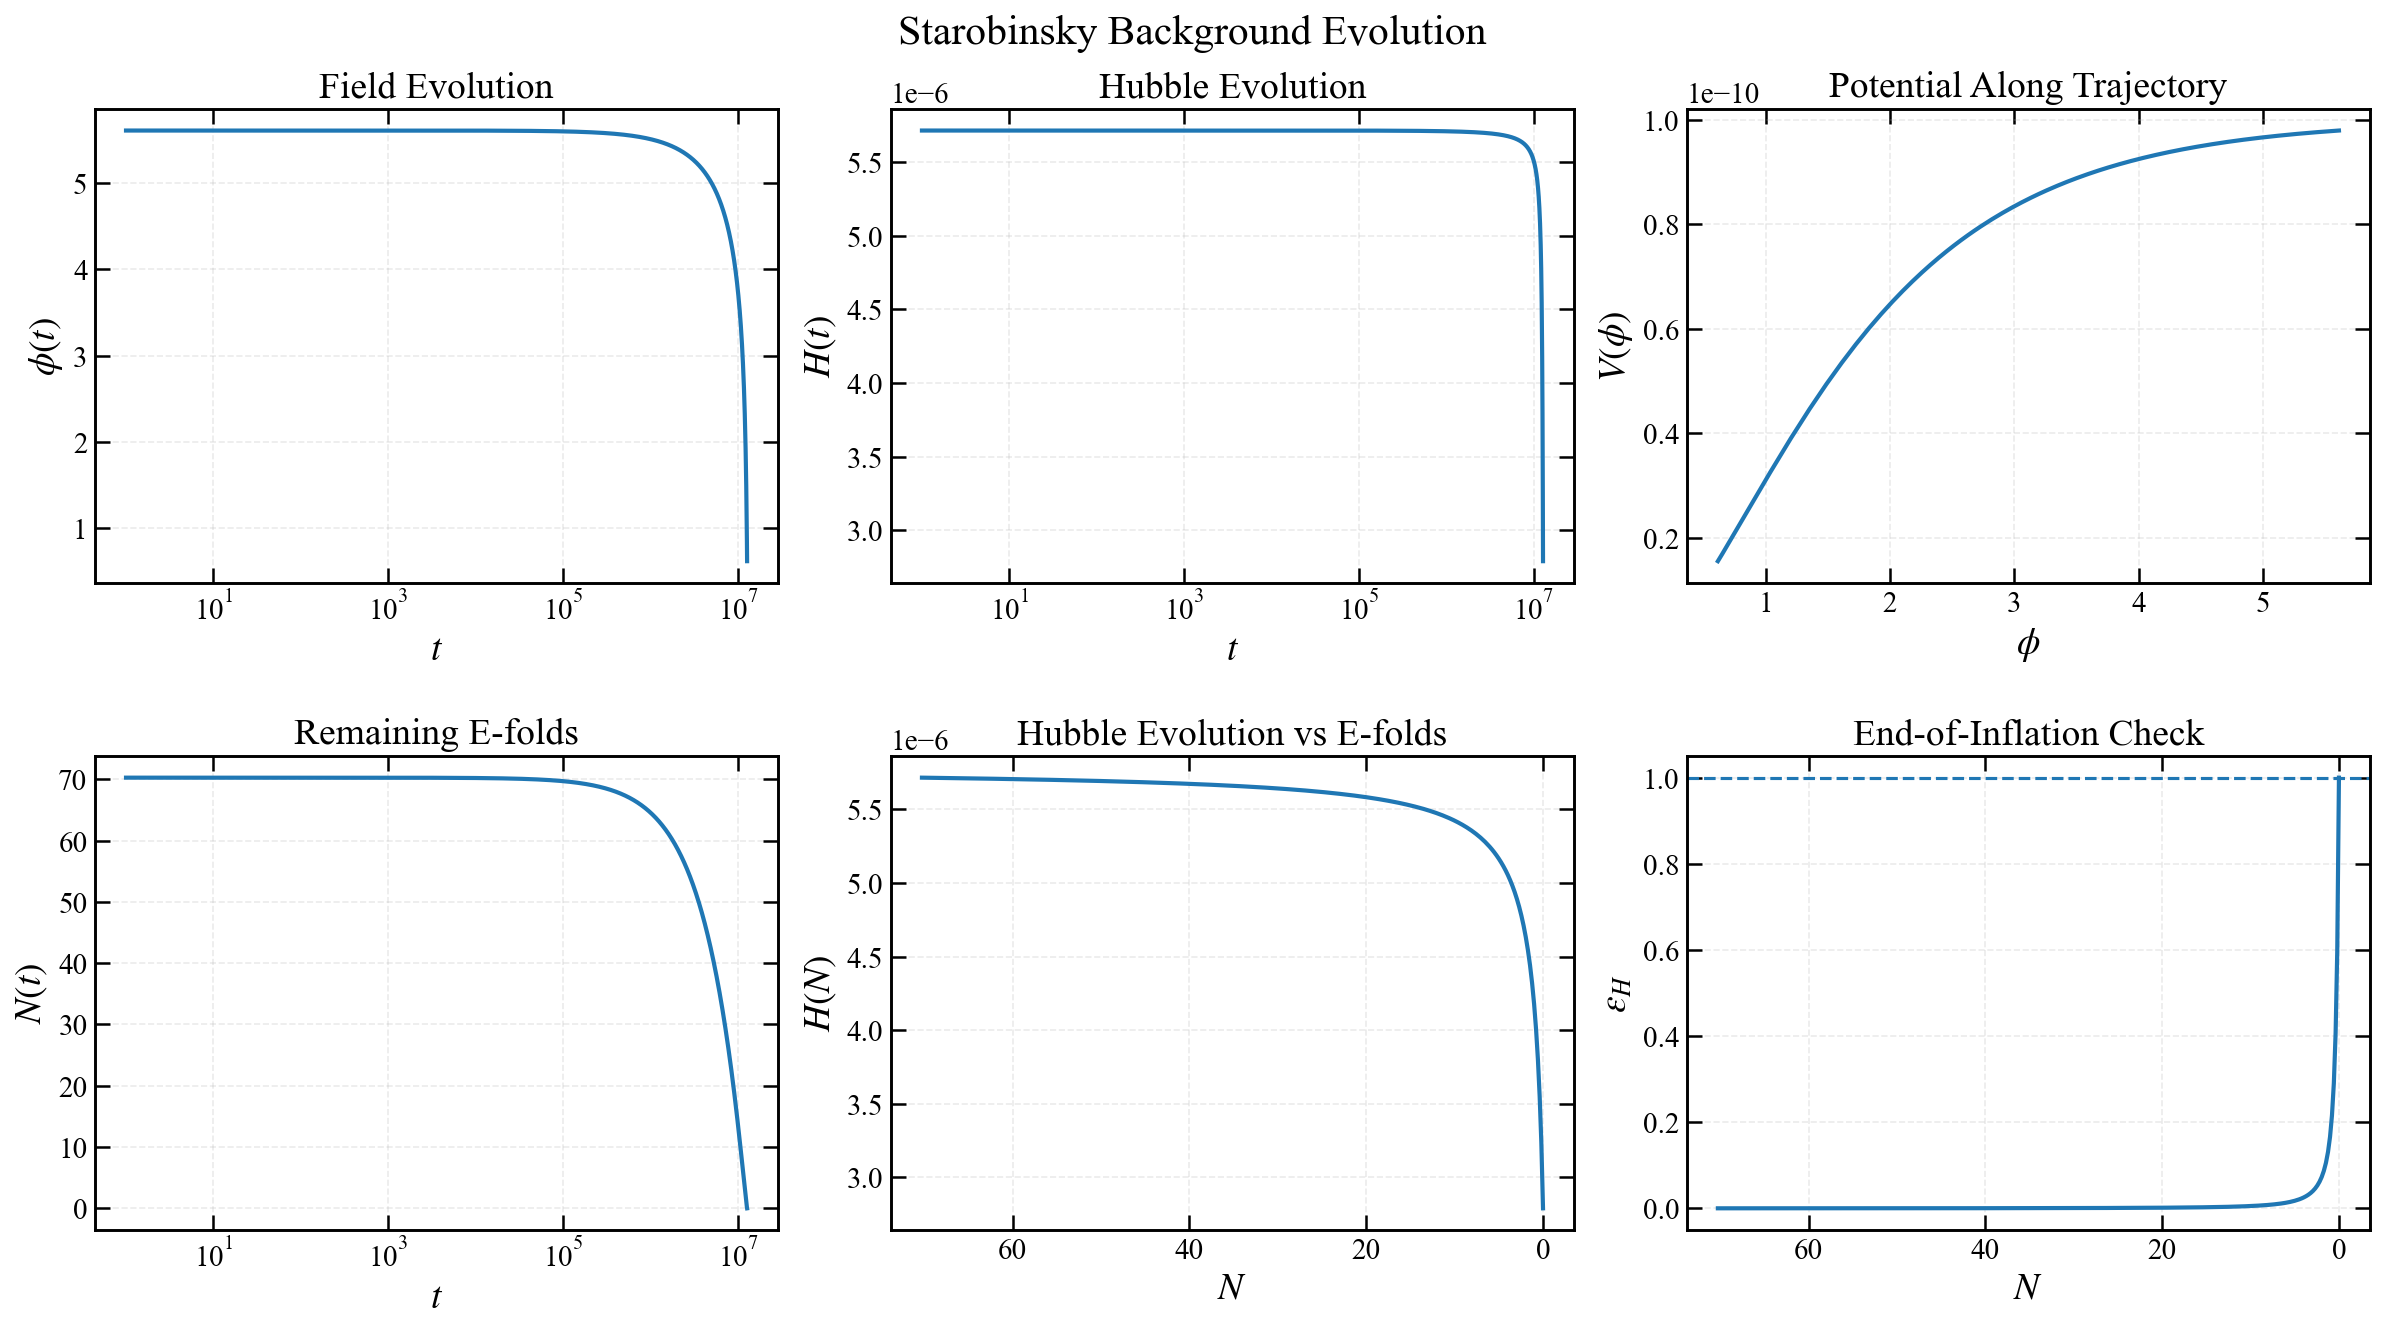


H positive: True
V positive: True
phi monotonic: True
direction: decreasing
epsilon initial: 0.0001429732723333436
epsilon final: 1.0000000000000009
N max: 70.26502651581862

Original points: 3790
After cleaning: 3790
Removed: 0

Saved: phi_H_V_N_clean_Starobinsky.csv



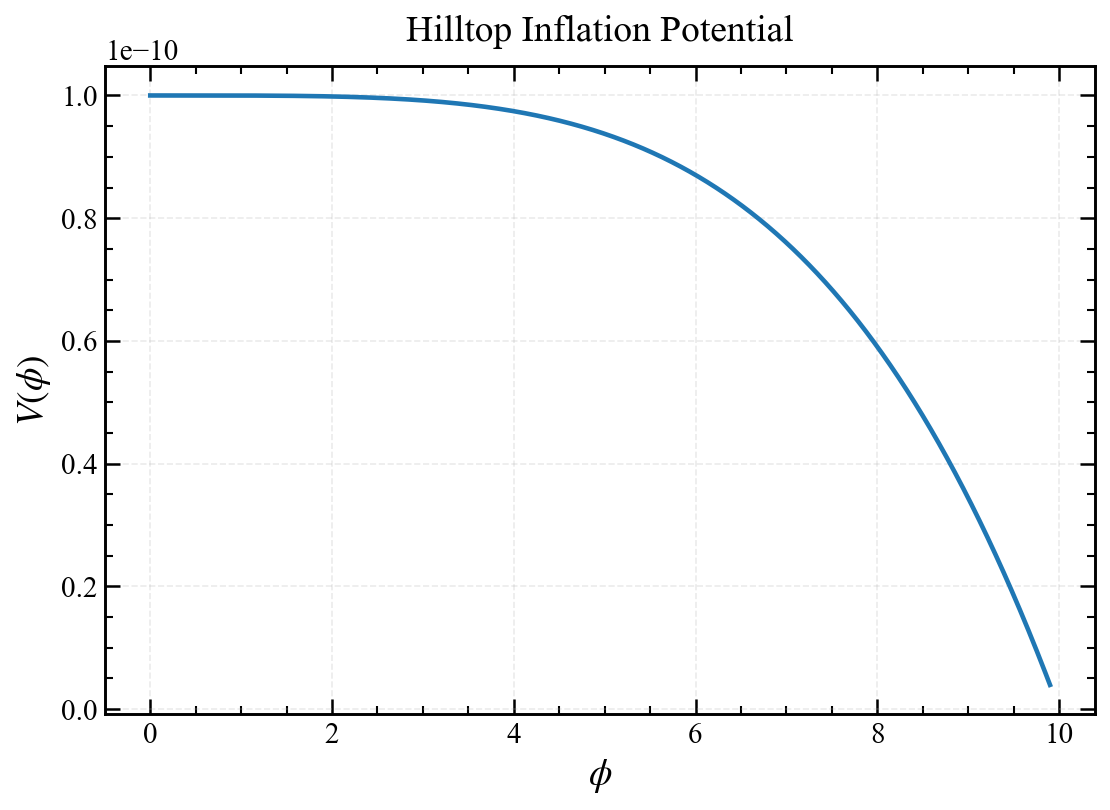


MODEL: Hilltop
Integration success: True
Message: A termination event occurred.

Initial phi: 3.65
Final phi: 9.65693706086796

Initial psi: 1.1330959716416423e-07
Final psi: 3.6100382684474613e-06

Initial epsilon_H: 0.0001960531136813667
Final epsilon_H: 1.000000000000007

Maximum remaining N: 71.77451927440201
epsilon_H = 1 reached: True
t_end: 13220699.395319432


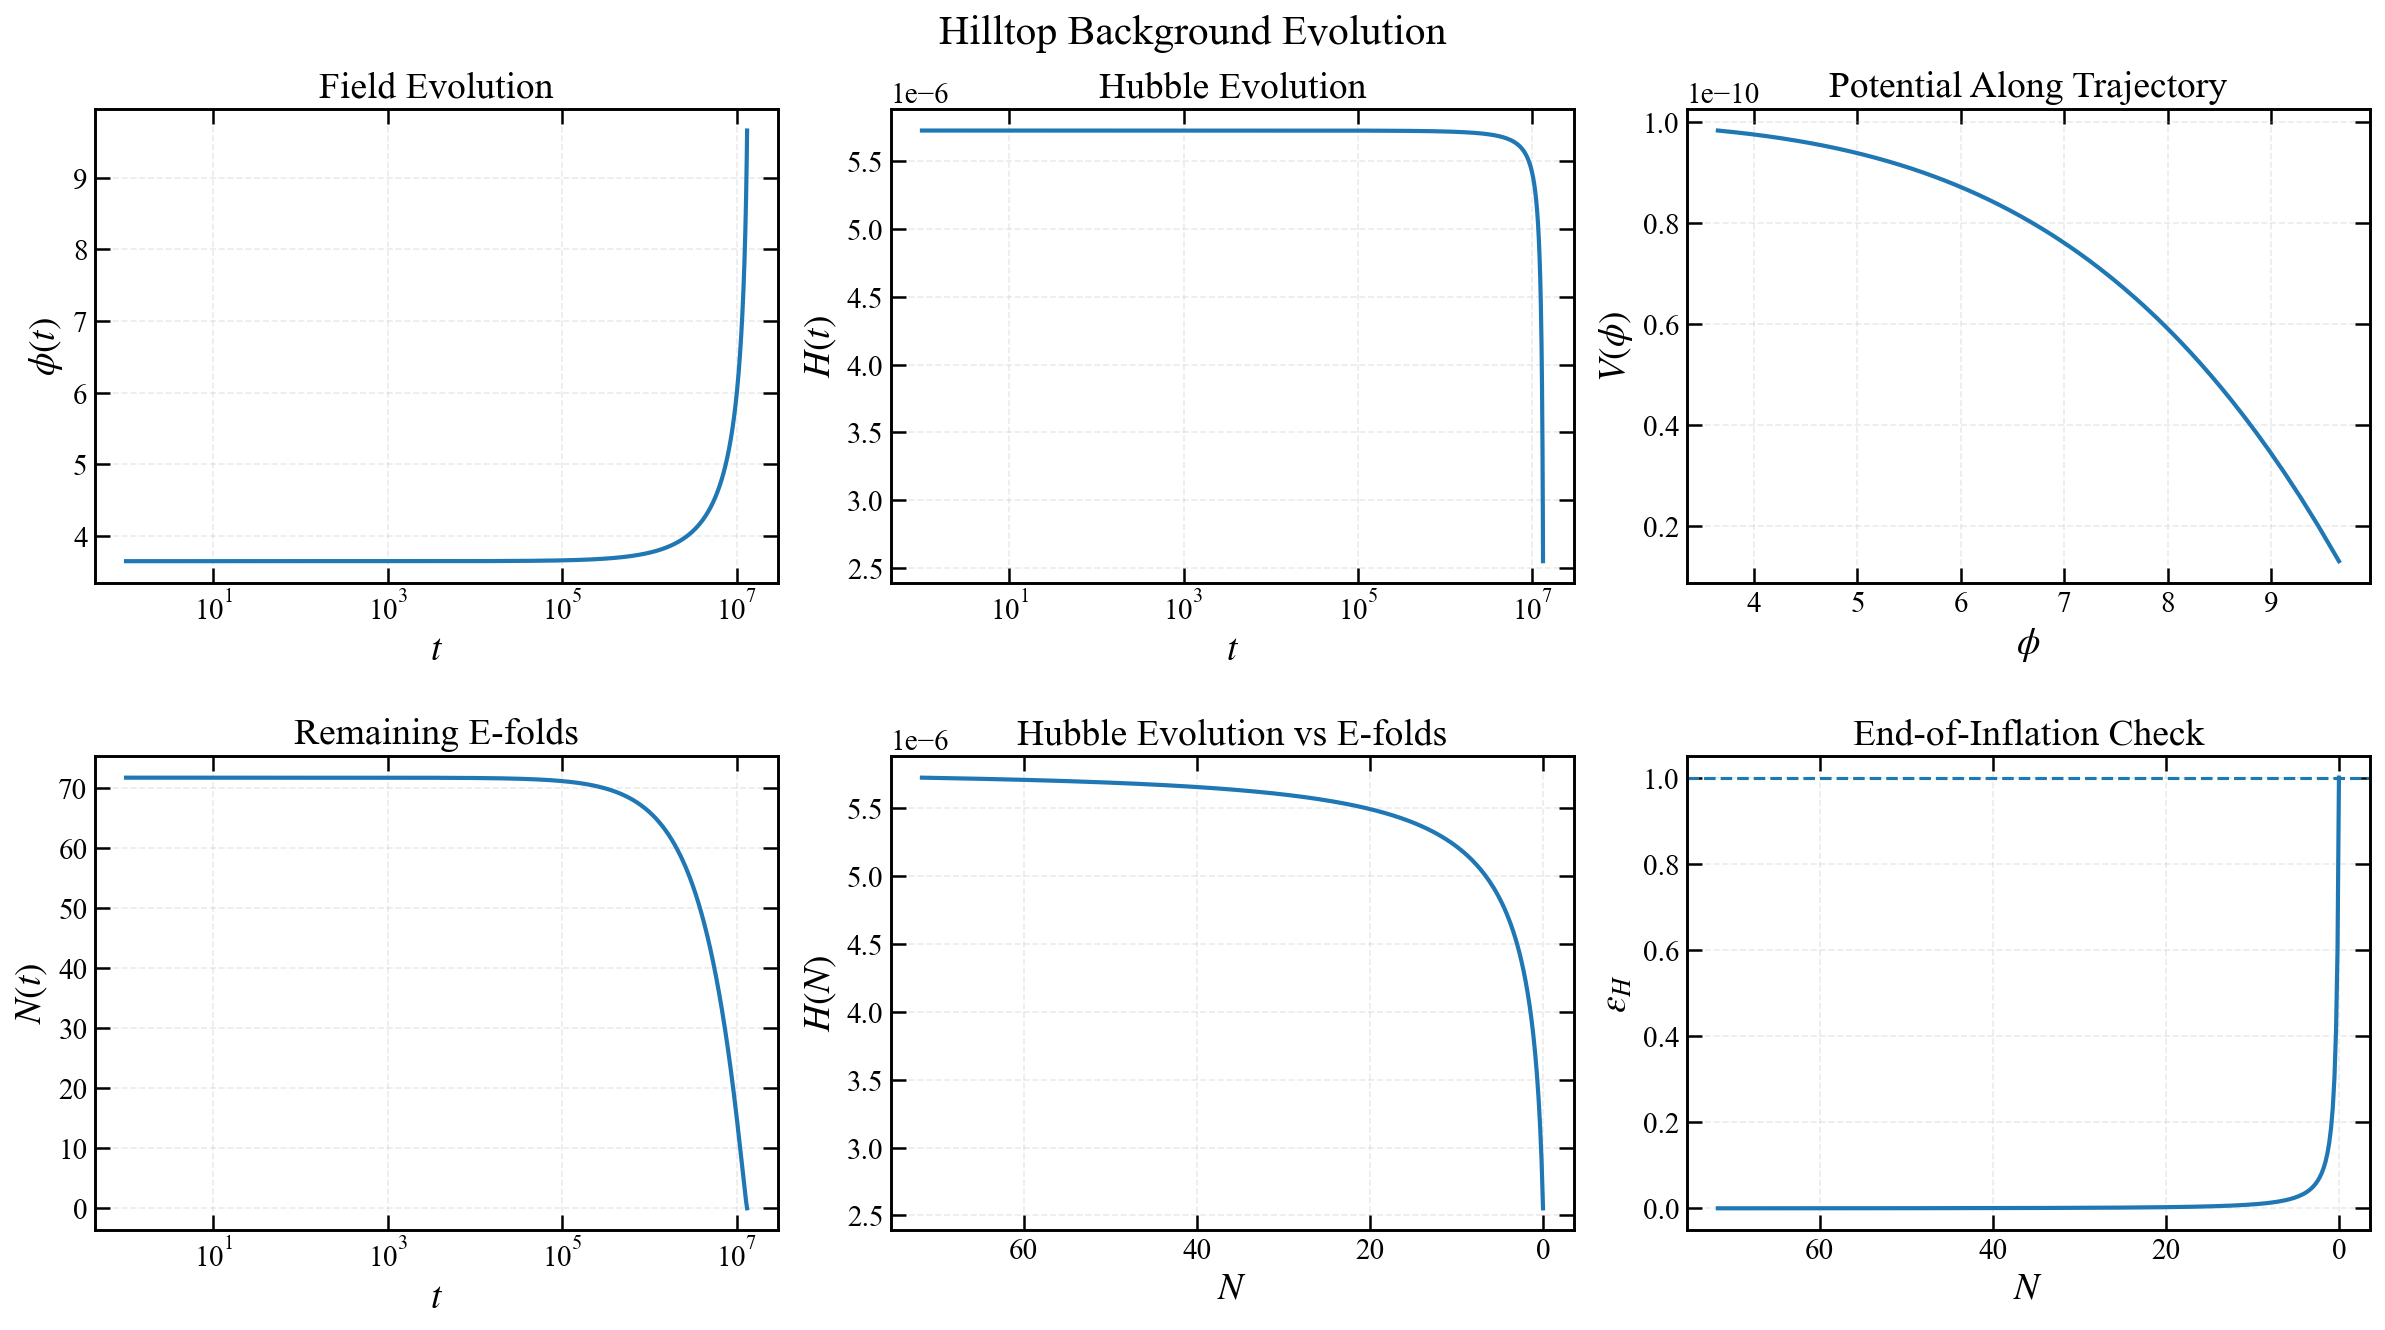


H positive: True
V positive: True
phi monotonic: True
direction: increasing
epsilon initial: 0.0001960531136813667
epsilon final: 1.000000000000007
N max: 71.77451927440201

Original points: 3799
After cleaning: 3799
Removed: 0

Saved: phi_H_V_N_clean_Hilltop.csv



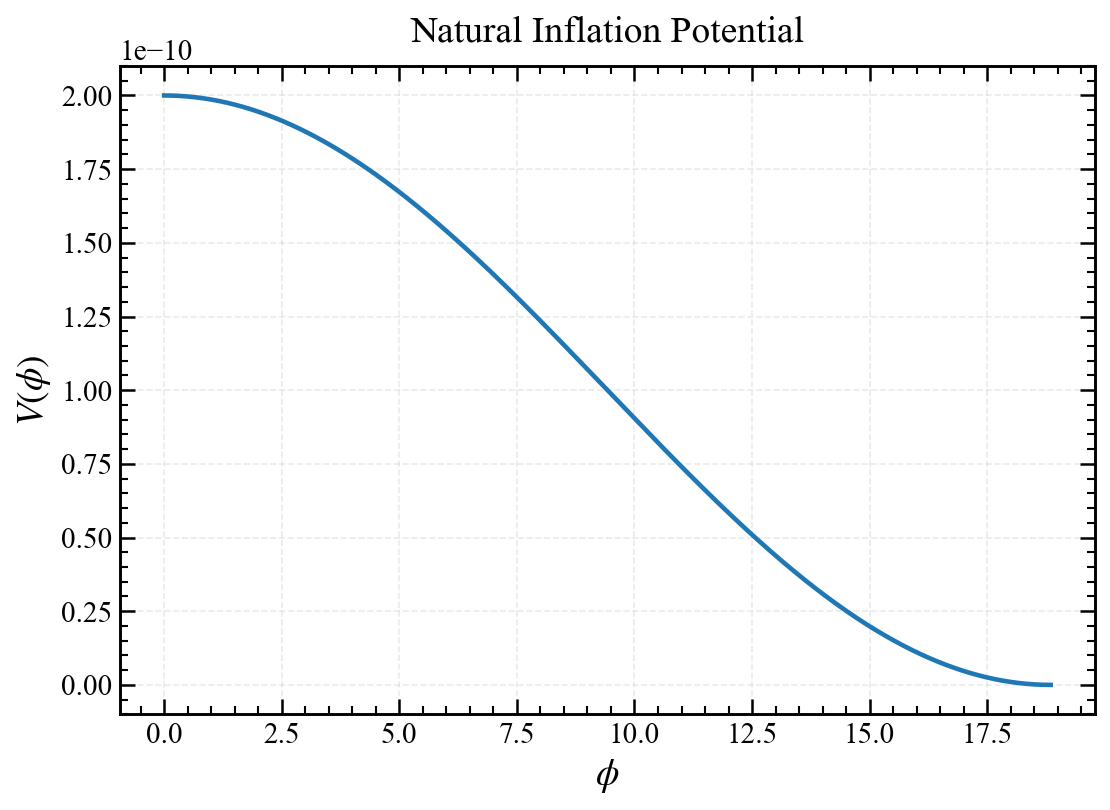


MODEL: Natural
Integration success: True
Message: A termination event occurred.

Initial phi: 4.6
Final phi: 17.84578850898978

Initial psi: 5.089685214377364e-07
Final psi: 1.181572230455648e-06

Initial epsilon_H: 0.002257150066296392
Final epsilon_H: 0.9999999999999952

Maximum remaining N: 71.5746637848835
epsilon_H = 1 reached: True
t_end: 13935607.44875684


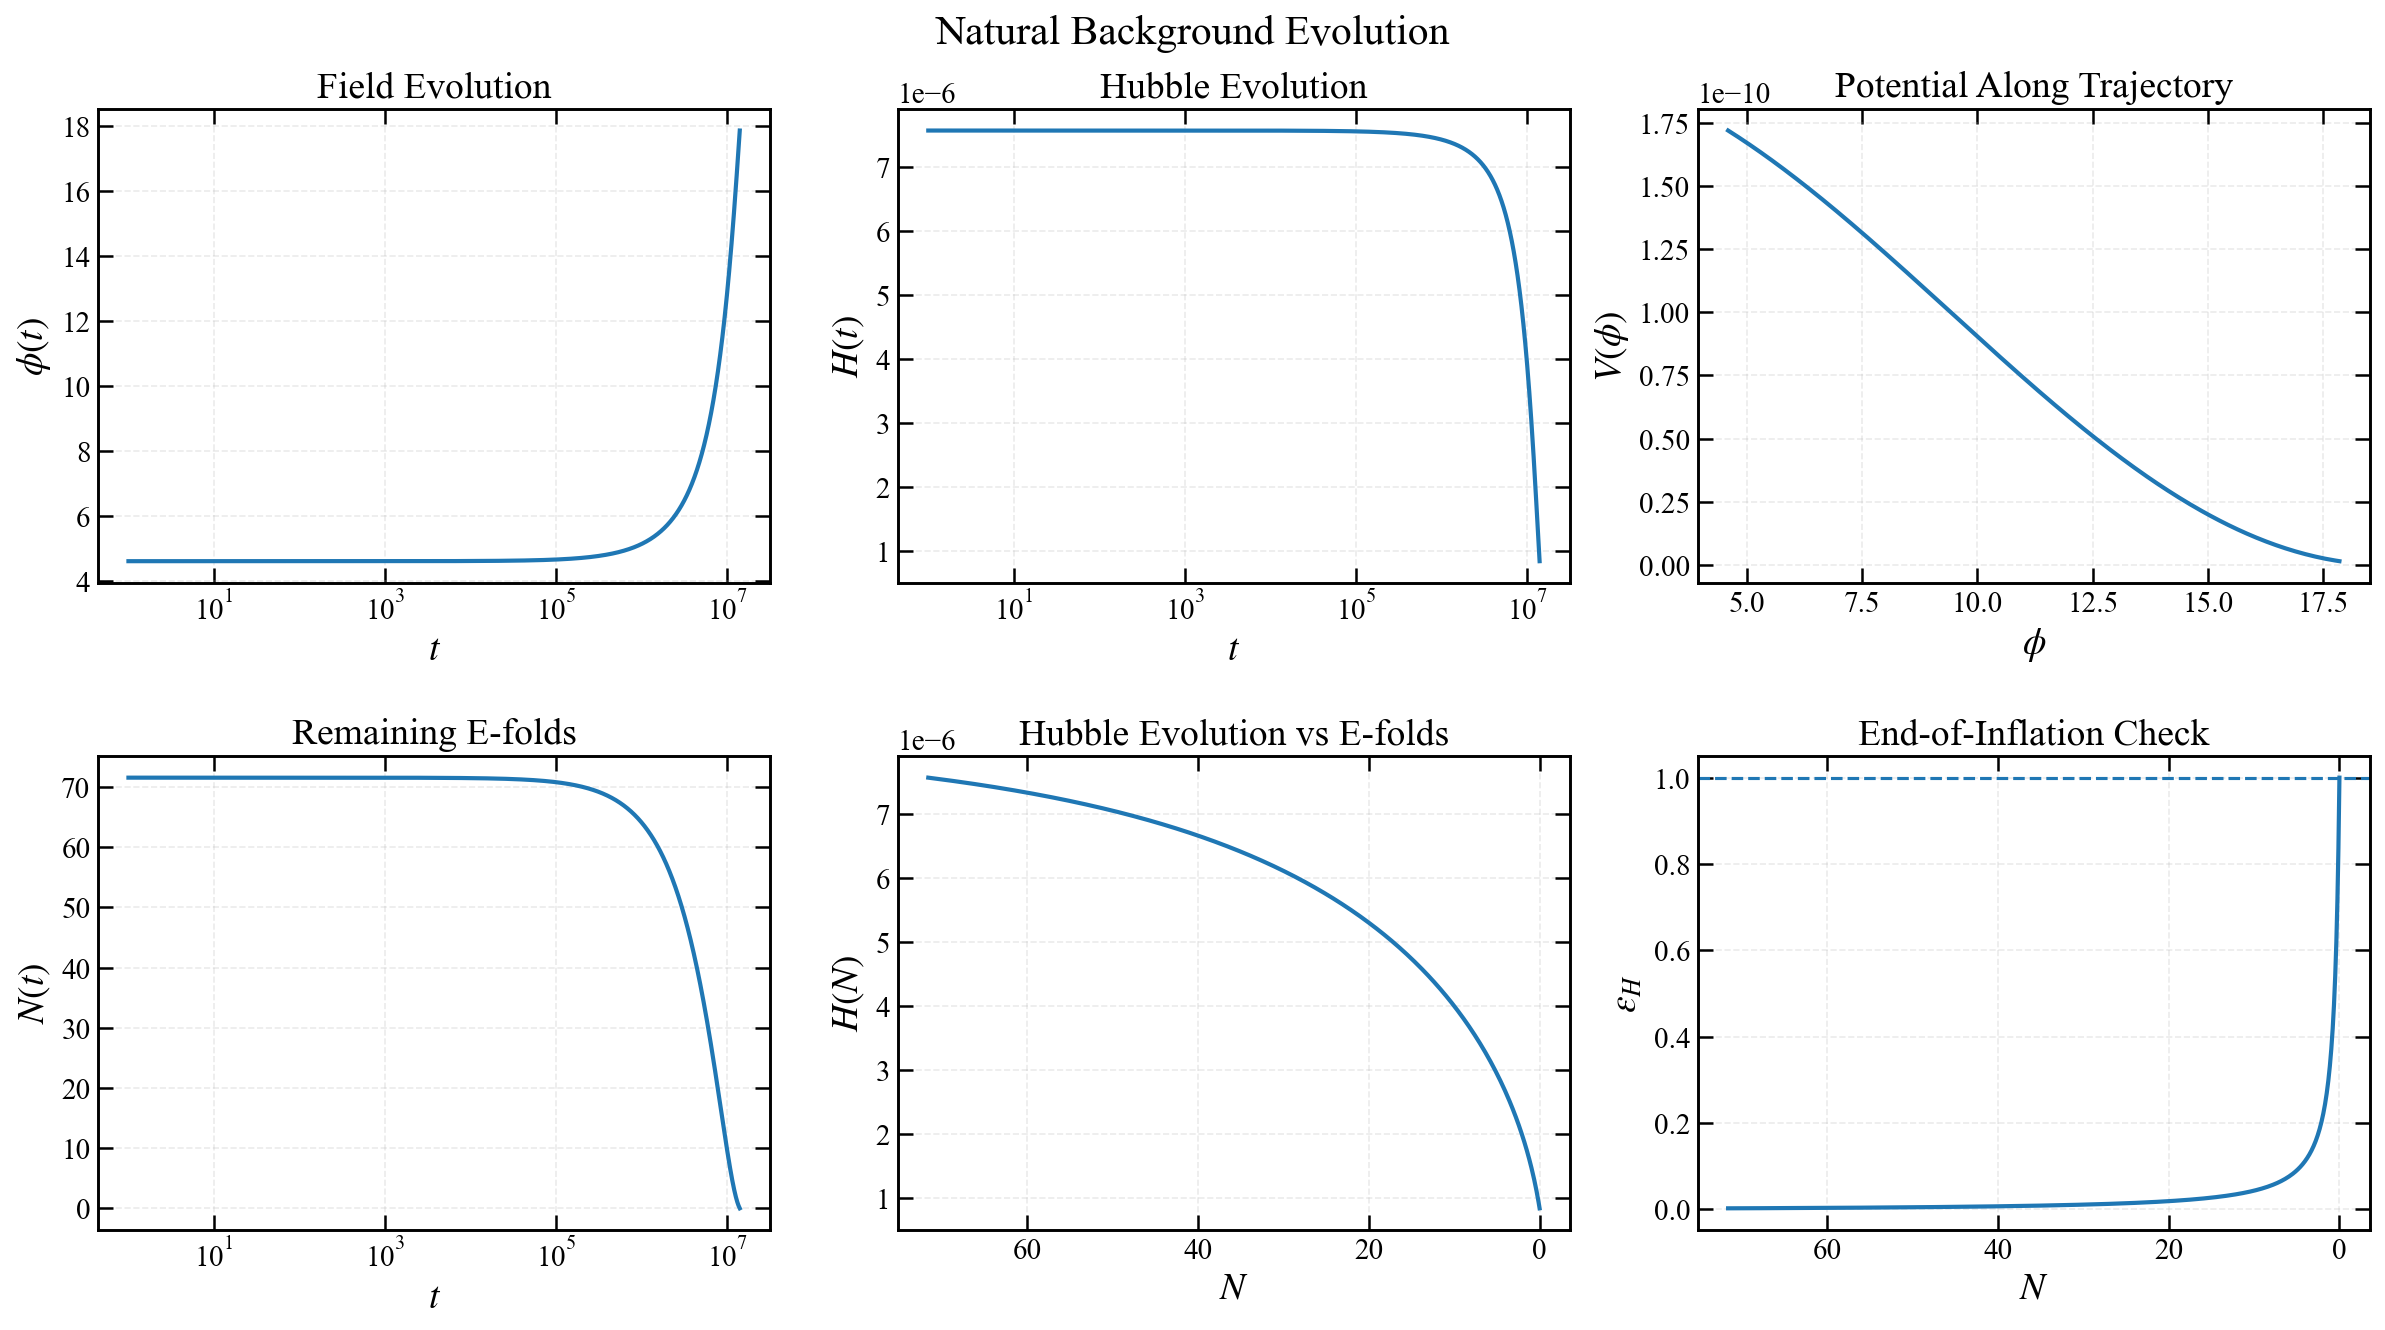


H positive: True
V positive: True
phi monotonic: True
direction: increasing
epsilon initial: 0.002257150066296392
epsilon final: 0.9999999999999952
N max: 71.5746637848835

Original points: 3811
After cleaning: 3811
Removed: 0

Saved: phi_H_V_N_clean_Natural.csv



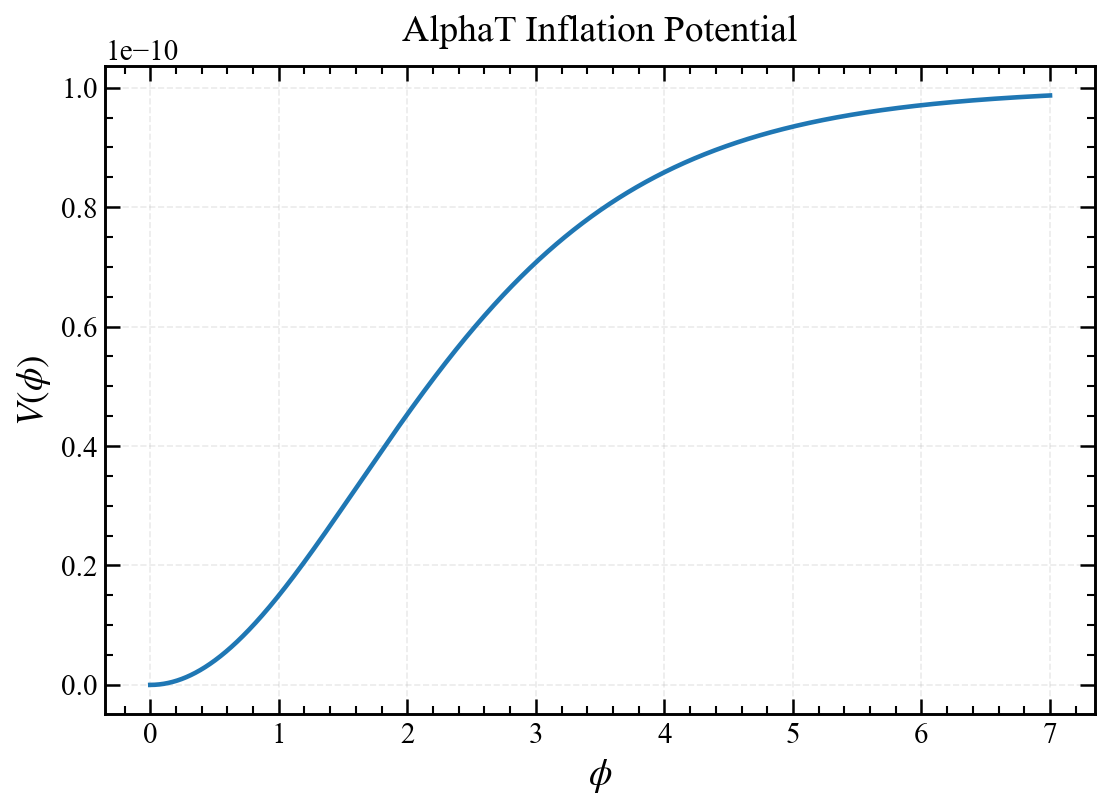


MODEL: AlphaT
Integration success: True
Message: A termination event occurred.

Initial phi: 6.4
Final phi: 0.8387320317233203

Initial psi: -1.0031269202606403e-07
Final psi: -3.2962806041448e-06

Initial epsilon_H: 0.00015421337268544795
Final epsilon_H: 0.9999999999999898

Maximum remaining N: 70.20777197919799
epsilon_H = 1 reached: True
t_end: 12838959.334418144


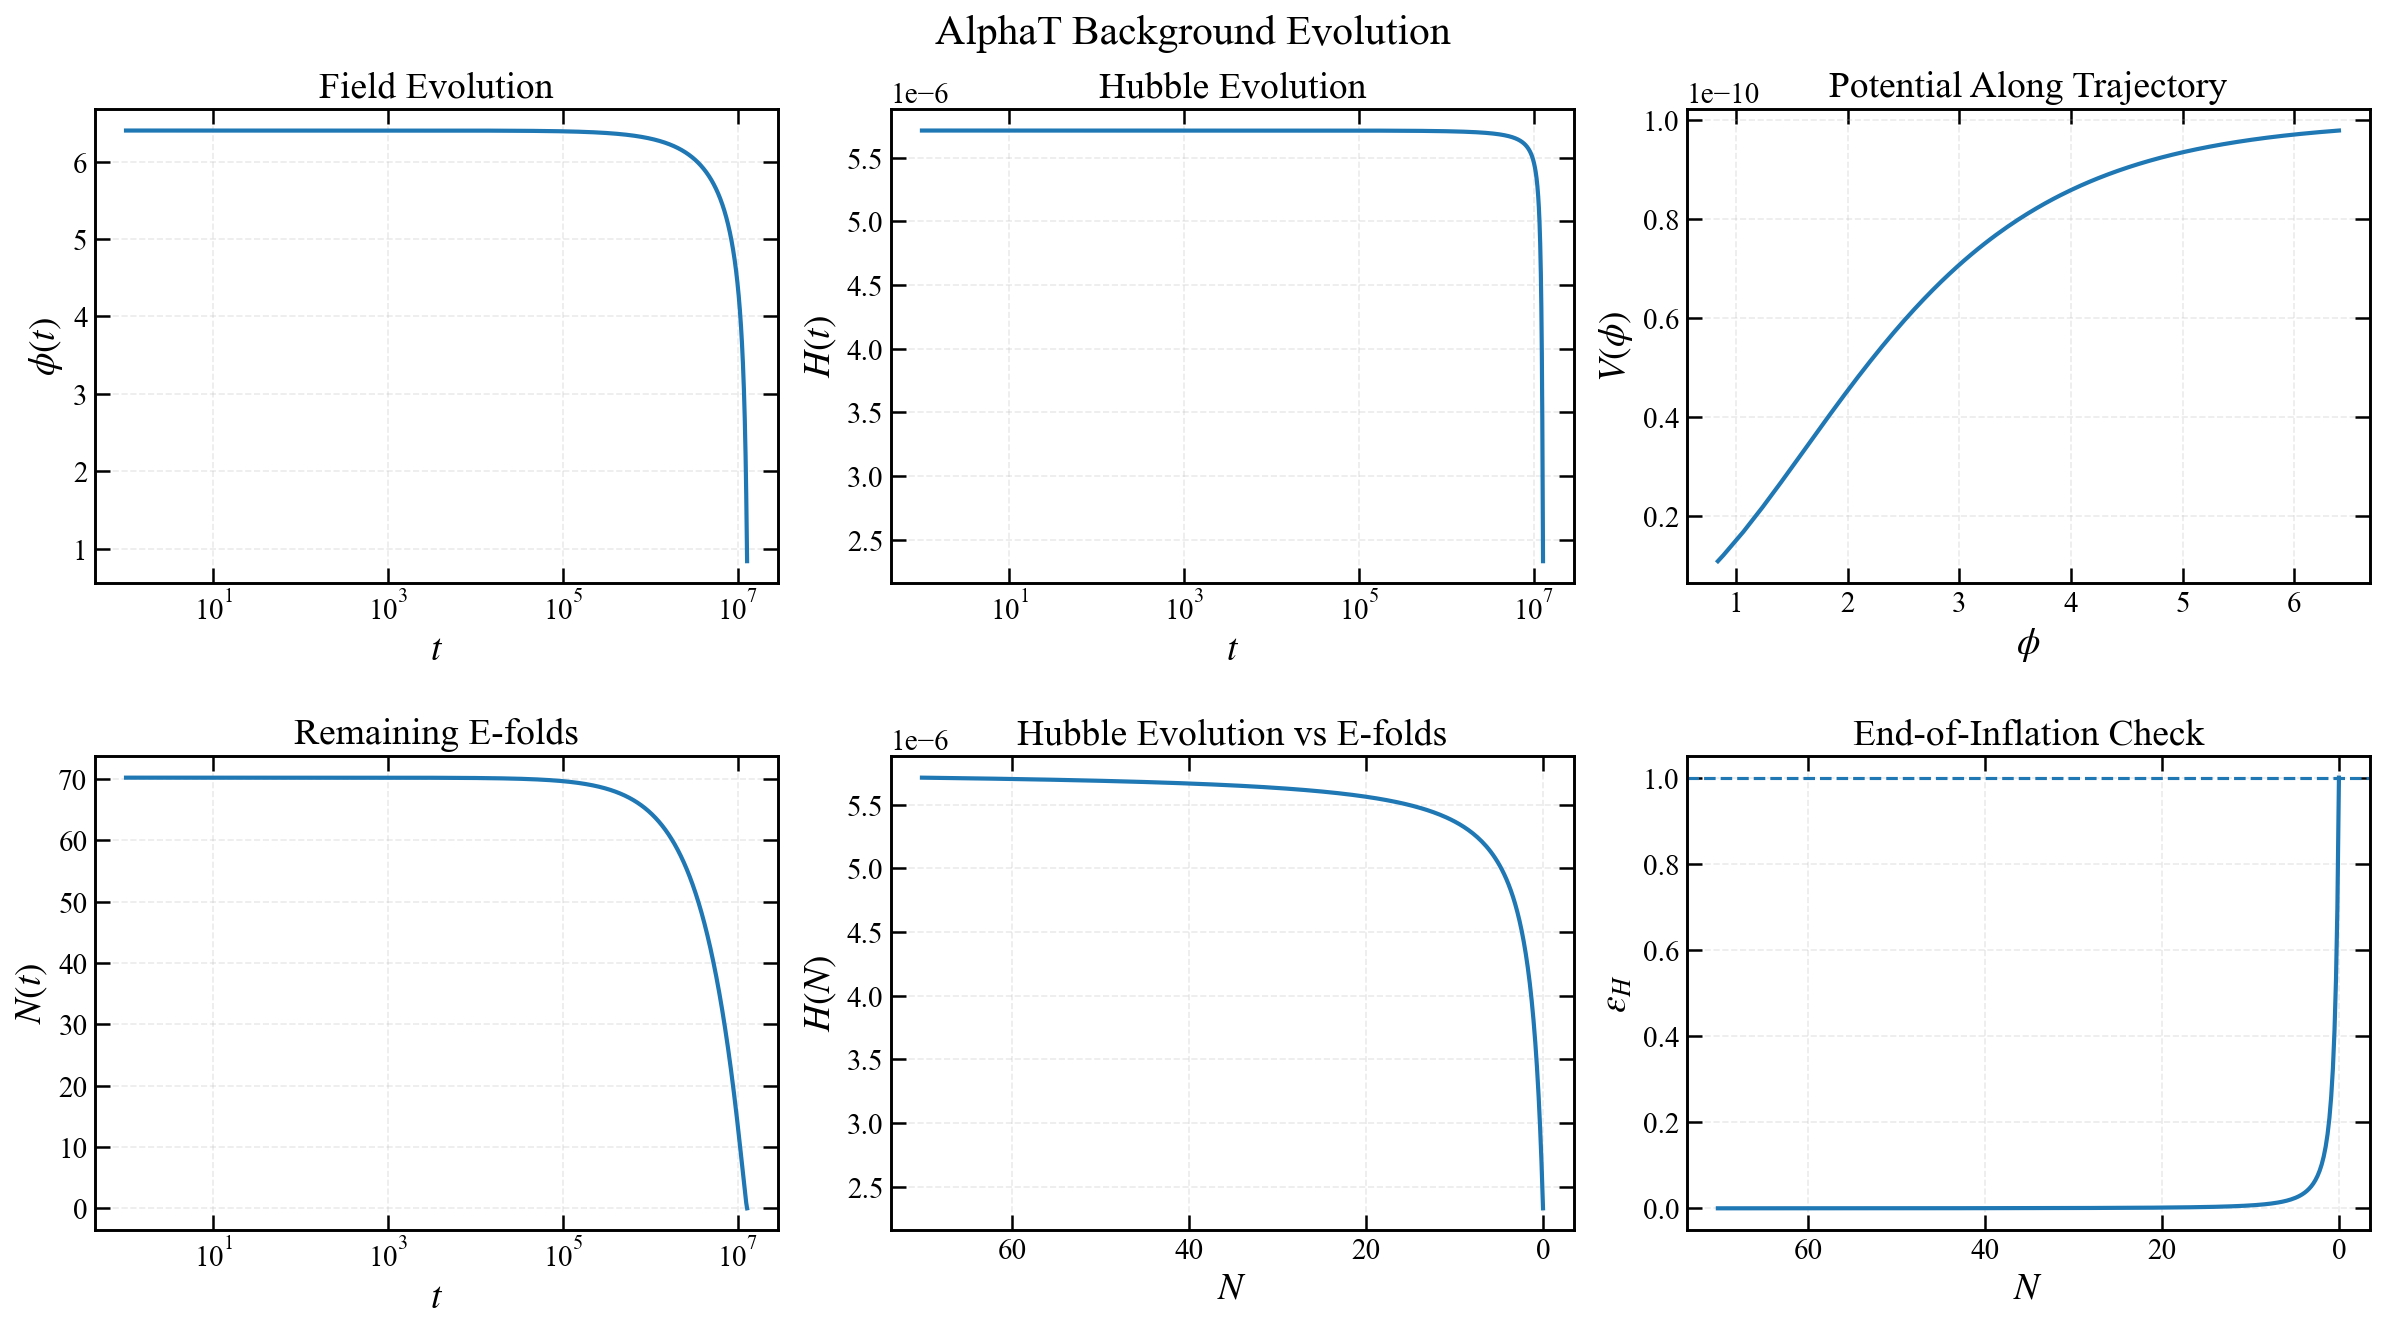


H positive: True
V positive: True
phi monotonic: True
direction: decreasing
epsilon initial: 0.00015421337268544795
epsilon final: 0.9999999999999898
N max: 70.20777197919799

Original points: 3792
After cleaning: 3792
Removed: 0

Saved: phi_H_V_N_clean_AlphaT.csv



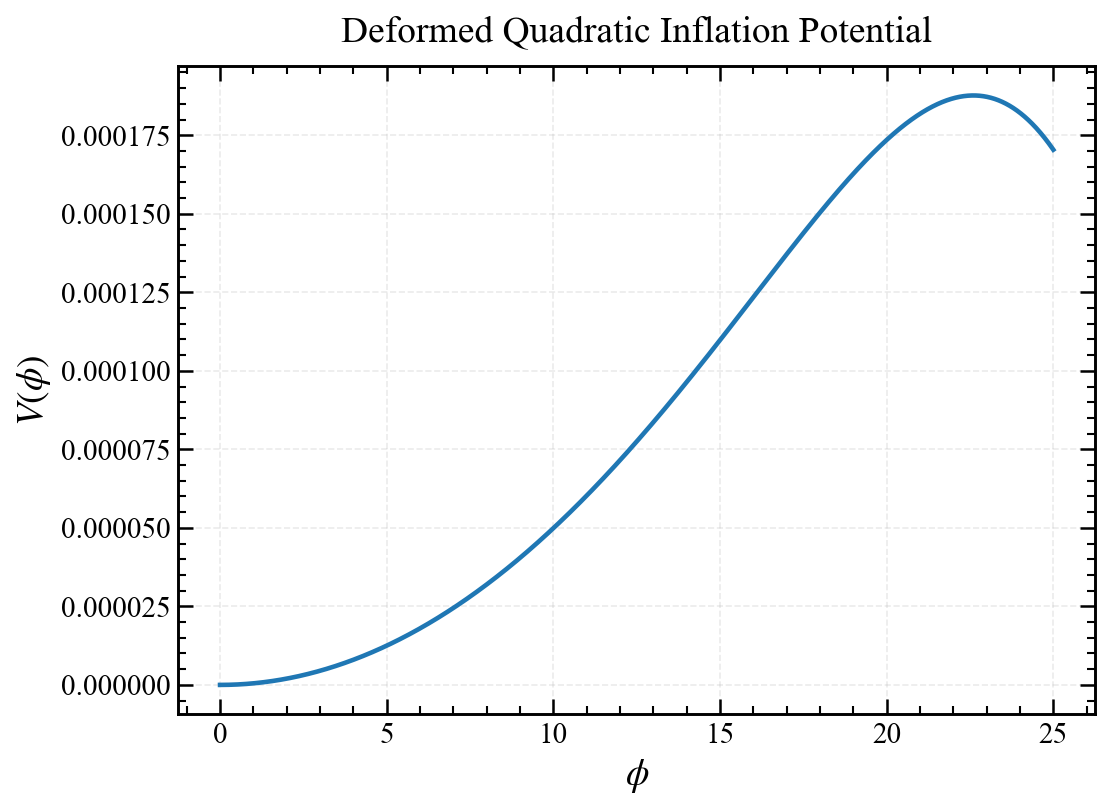


MODEL: Deformed Quadratic
Integration success: True
Message: A termination event occurred.

Initial phi: 16.4
Final phi: 1.009342584605427

Initial psi: -0.0006973507851852071
Final psi: -0.0007137129853062826

Initial epsilon_H: 0.005646977282269996
Final epsilon_H: 1.0000000000000002

Maximum remaining N: 70.15227385568787
epsilon_H = 1 reached: True
t_end: 19581.267997937593


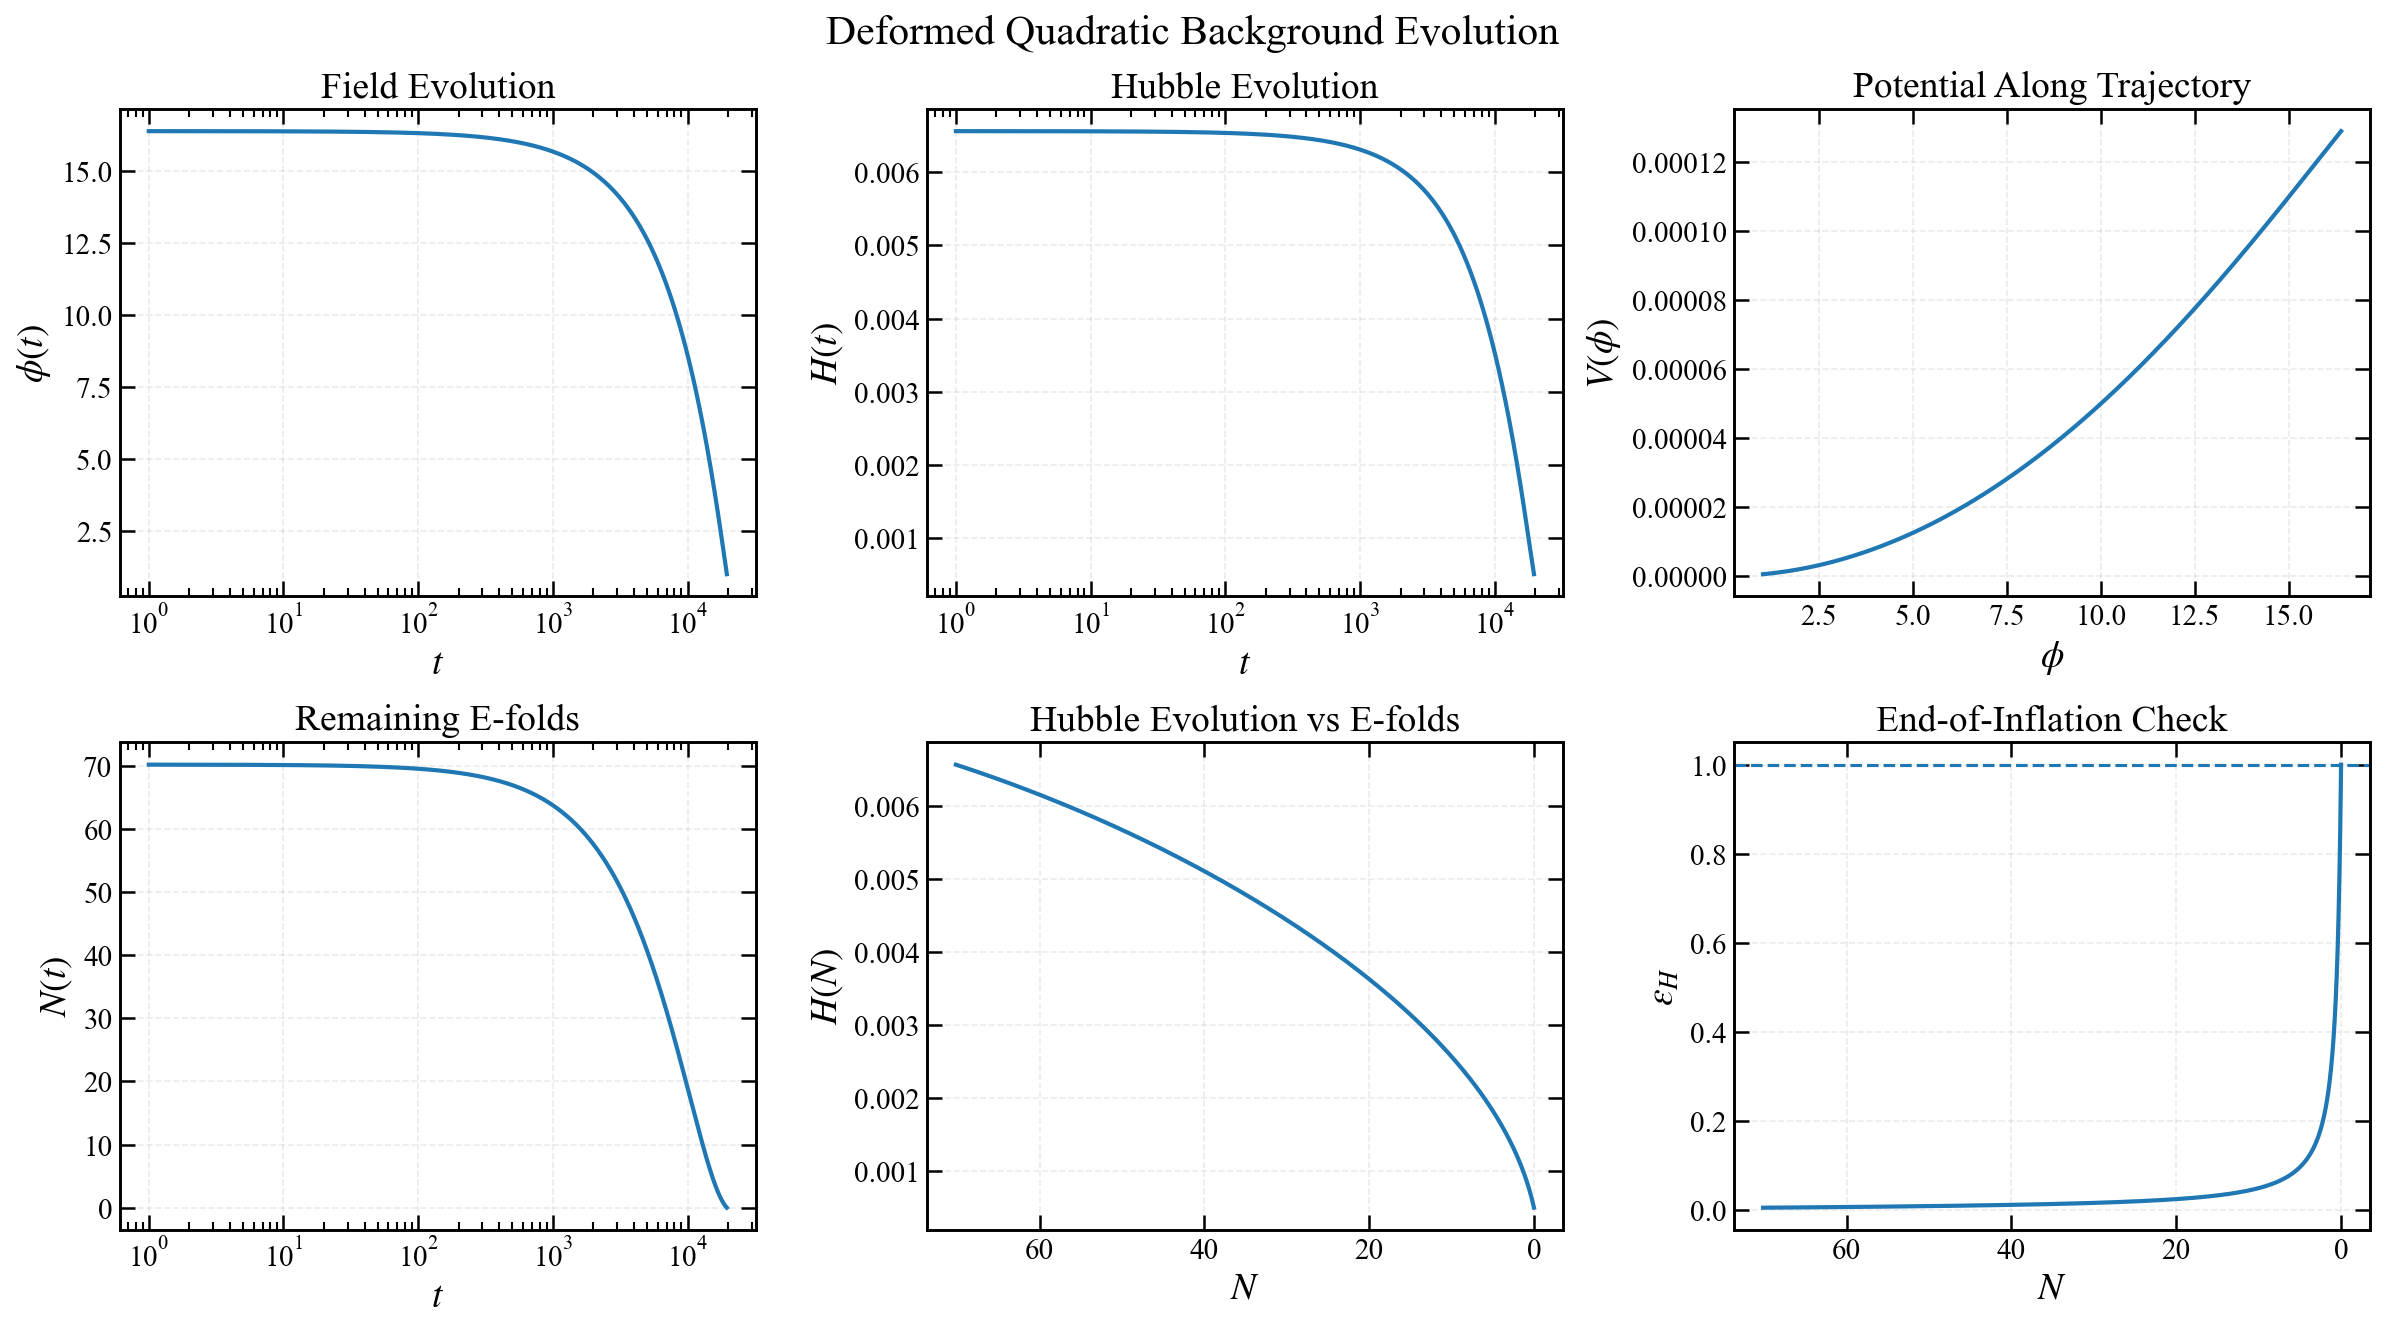


H positive: True
V positive: True
phi monotonic: True
direction: decreasing
epsilon initial: 0.005646977282269996
epsilon final: 1.0000000000000002
N max: 70.15227385568787

Original points: 2290
After cleaning: 2290
Removed: 0

Saved: phi_H_V_N_clean_Deformed_Quadratic.csv


MODEL: Higgs
Initial phi: 5.4
Final phi: -0.8564378752131839
Initial psi: -1.1473823565017132e-07
Final psi: -2.71002796450714e-07
Maximum remaining N: 61.44220213291778


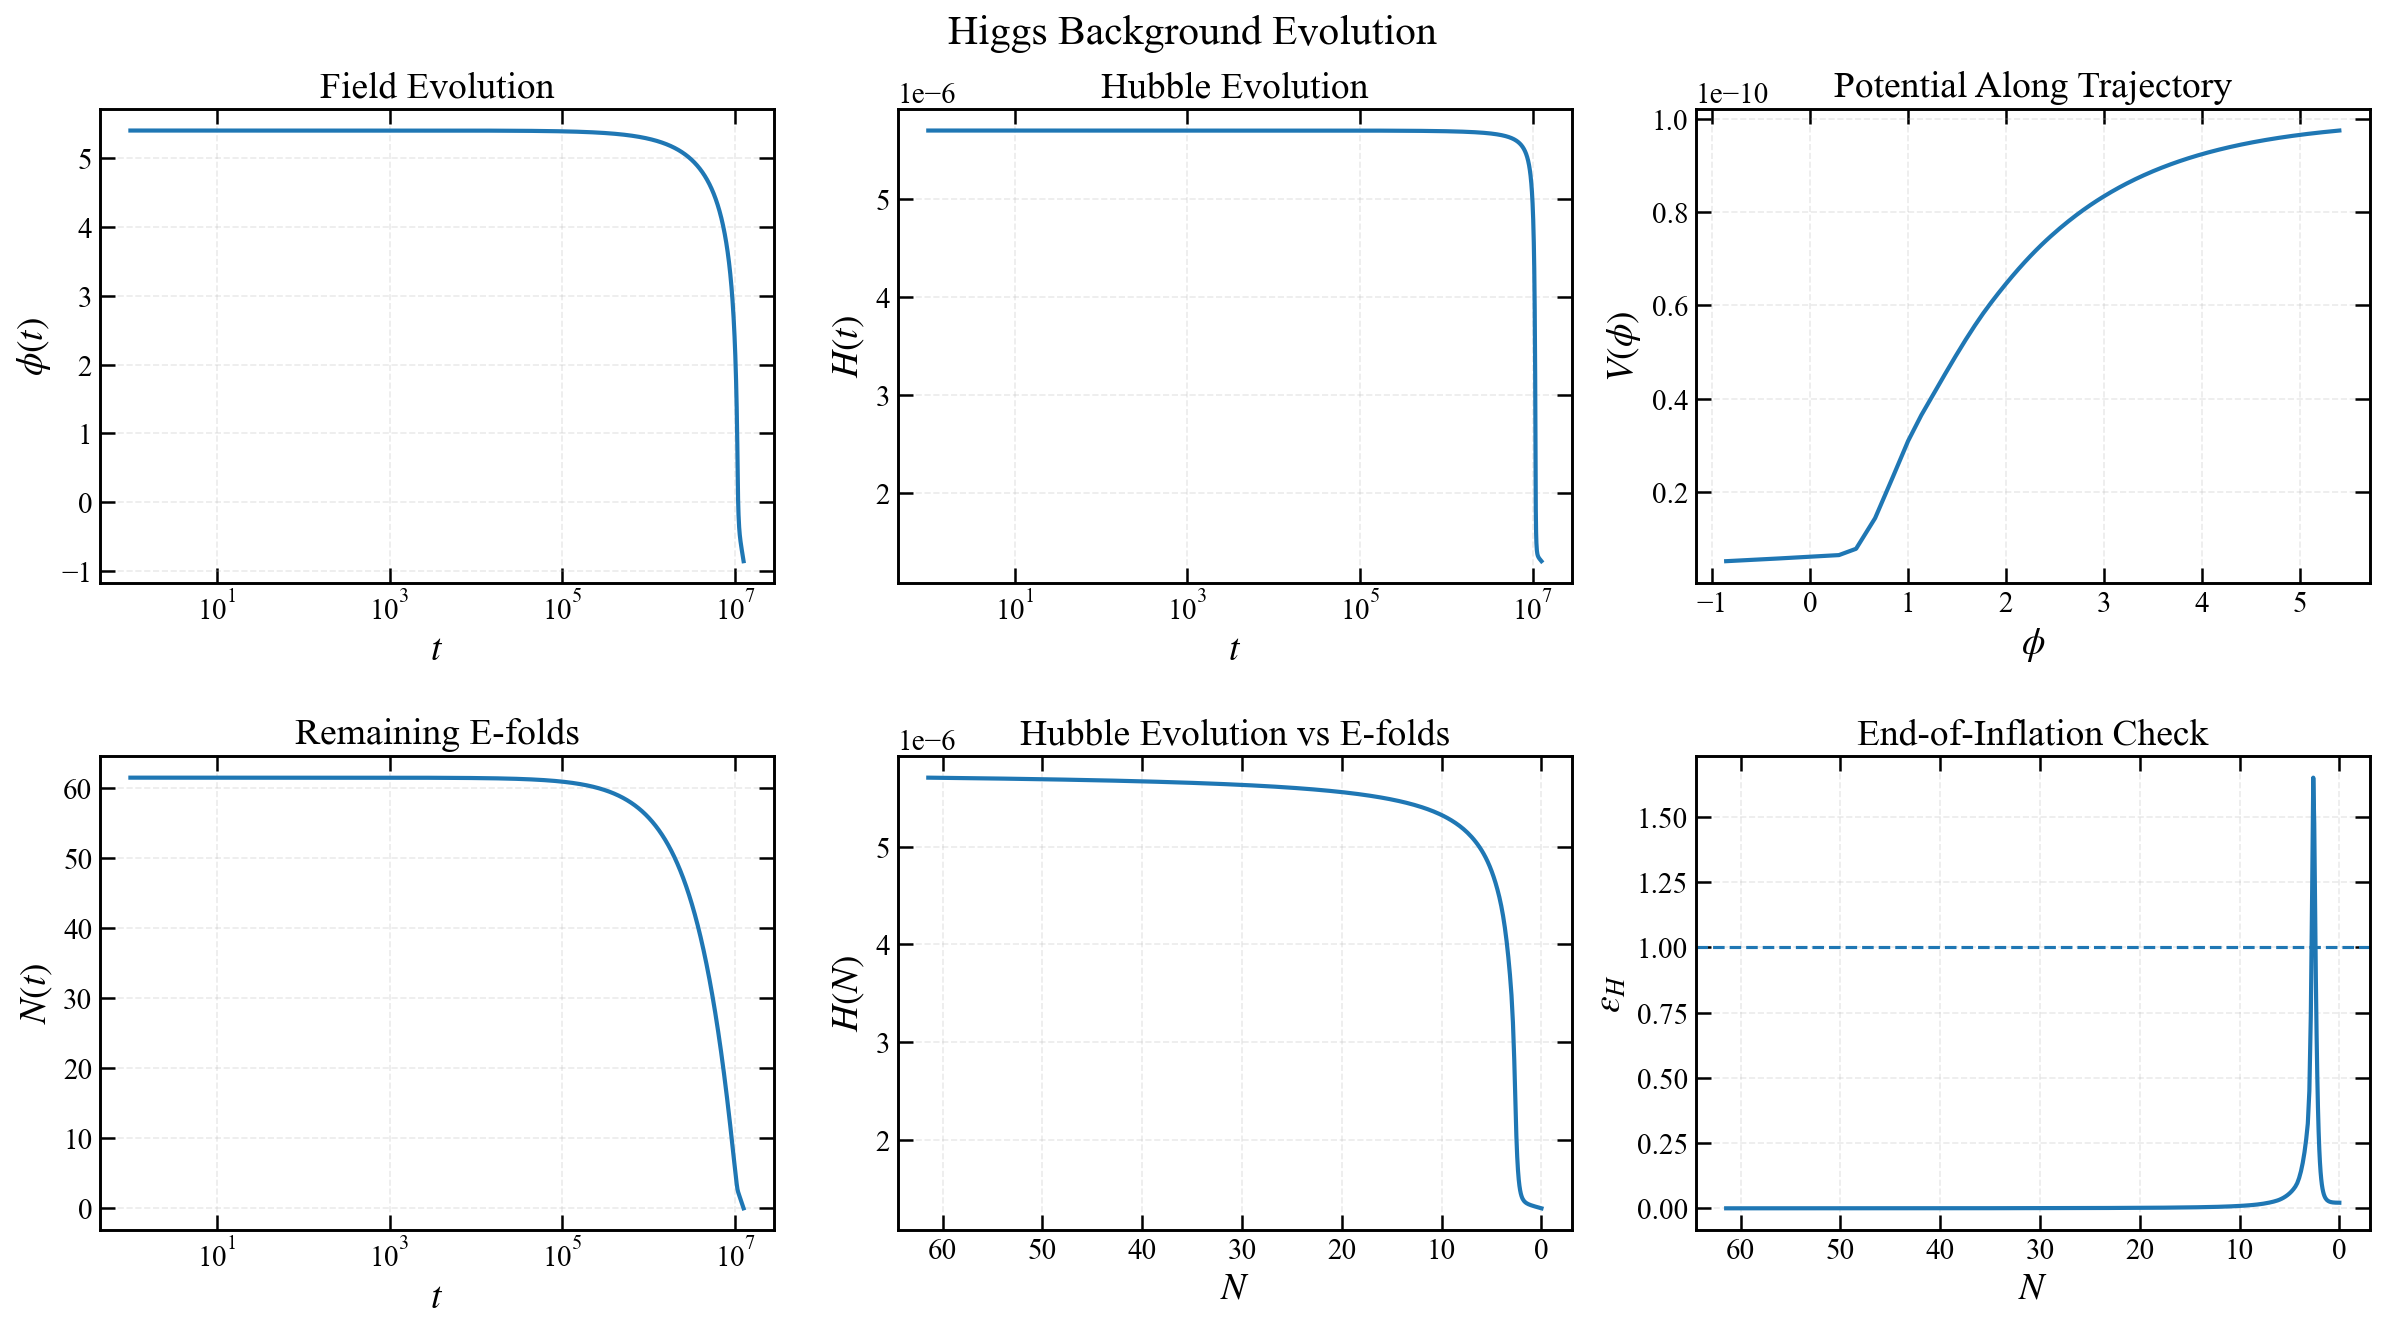


Original points: 4000
After cleaning: 4000
Removed: 0

Higgs results returned only.
Higgs file NOT saved.



In [86]:
models = [
    "Starobinsky",
    "Hilltop",
    "Natural",
    "AlphaT",
    "Deformed_Quad",
    "Higgs"
]

trajectory_data = {}

for model_name in models:

    phi, H, V, N = run_model(model_name)

    trajectory_data[model_name] = {
        "phi": phi,
        "H": H,
        "V": V,
        "N": N
    }

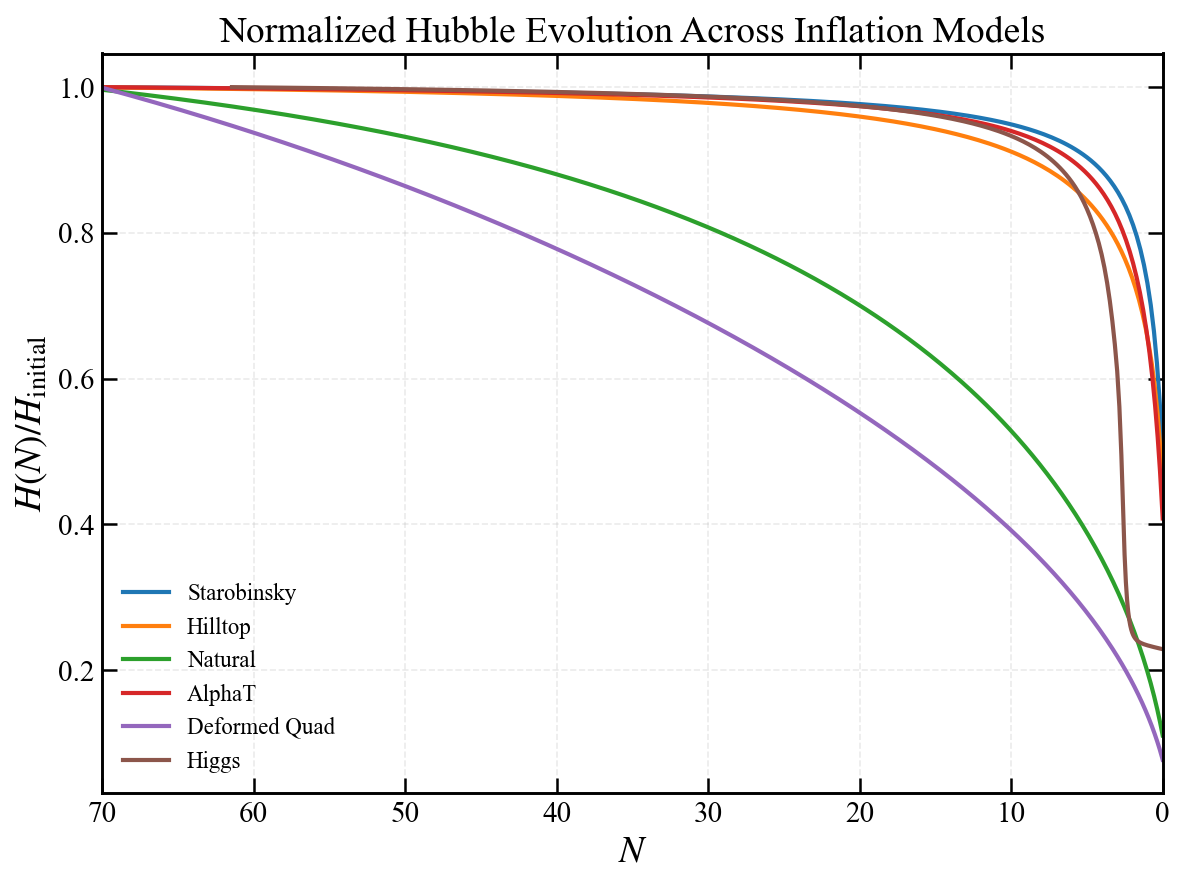

In [91]:
# ============================================================
# Normalized H(N): all models overlaid
# ============================================================

plt.figure(figsize=(8, 6))

for model_name in models:

    data = trajectory_data[model_name]

    N_vals = data["N"]
    H_vals = data["H"]

    # Normalize to the initial H value for that model
    H_norm = H_vals / H_vals[0]

    plt.plot(
        N_vals,
        H_norm,
        linewidth=2.0,
        label=model_name.replace("_", " ")
    )

plt.xlabel(r"$N$")
plt.ylabel(r"$H(N)/H_{\rm initial}$")

plt.title(
    r"Normalized Hubble Evolution Across Inflation Models"
)

plt.grid(
    alpha=0.25,
    linestyle="--"
)

plt.xlim(0,70)

plt.tick_params(
    which="both",
    direction="in",
    top=True,
    right=True
)

plt.legend(
    frameon=False,
    fontsize=11
)

plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()
